# Set Up

## A. Library

Menginstall Library: (1) Pytorch dan (2) Transformer

In [1]:
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124
%pip install transformers
# %pip install umap-learn

Looking in indexes: https://download.pytorch.org/whl/cu124
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Mengimport Library

In [3]:
import os
import torch
import logging
import warnings
import numpy as np
import pandas as pd
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, Dataset
import torch.optim as optim
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, classification_report
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.patches as mpatches
import umap.umap_ as umap
import gc



## B. Device

Melakukan Set Up Device:<br>(1) Mendeteksi Hardware,<br>(2) Melakukan Konfigurasi Device yang Akan Digunakan Dalam Eksperimen ini,<br>(3) Memastikan Komputasi Berjalan di GPU

In [4]:
# =========================================================
# 1. SETUP LIBRARY & DEVICE
# =========================================================

print("-" * 50)
# Logika pendeteksian perangkat
# Jika CUDA (GPU NVIDIA) tersedia, gunakan 'cuda'. Jika tidak, pakai 'cpu'.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device yang digunakan: {device}")

if torch.cuda.is_available():
    print(f"Nama GPU: {torch.cuda.get_device_name(0)}")
    print(f"Versi CUDA: {torch.version.cuda}")
else:
    print("Peringatan: GPU tidak terdeteksi. Proses akan berjalan lambat di CPU.")
print("-" * 50)

os.environ["DISABLE_SAFETENSORS_CONVERSION"] = "1"

--------------------------------------------------
Device yang digunakan: cuda
Nama GPU: NVIDIA GeForce RTX 3060 Laptop GPU
Versi CUDA: 12.4
--------------------------------------------------


## C. Model

### 1. Load Model IndoBERT (Versi IndoLEM)

Load Model IndoBERT Versi IndoLEM (Koto et al., 2020)

In [5]:
print("Melakukan Loading Model IndoBERT (IndoLEM):")
print("="*75)
indobert_name = "indolem/indobert-base-uncased"
tokenizer_indobert = AutoTokenizer.from_pretrained(indobert_name)
model_indobert = AutoModel.from_pretrained(indobert_name, output_hidden_states=True).to(device)
model_indobert.eval() # Set ke mode evaluasi agar setiap dijalankan tidak terjadi perubahan pada bobot model
print("Info: Model IndoBERT berhasil dimuat✅")
print("="*75)

Melakukan Loading Model IndoBERT (IndoLEM):


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: indolem/indobert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Info: Model IndoBERT berhasil dimuat✅


Note: Model yang Diload Menggunakan Model Evaluasi Dikarnakan Kita Hanya Ingin Mengekstrak Representasinya Saja Sehingga Komponen Dropout-nya Perlu untuk Dimatikan Agar Representasi yang Keluar dari Tiap Lapisan Tidak Akan Berubah-ubah Setiap Kali Dijalankan

### 2. Load Model XLM-R

In [6]:
print("Melakukan Loading Model XLM-R:")
print("="*75)
xlmr_name = "xlm-roberta-base"
tokenizer_xlmr = AutoTokenizer.from_pretrained(xlmr_name)
model_xlmr = AutoModel.from_pretrained(xlmr_name, output_hidden_states=True).to(device)
model_xlmr.eval() # Set ke mode evaluasi agar setiap dijalankan tidak terjadi perubahan pada bobot model
print("Info: Model XLM-R berhasil dimuat✅")
print("="*75)

Melakukan Loading Model XLM-R:


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Info: Model XLM-R berhasil dimuat✅


Note: Model yang Diload Menggunakan Model Evaluasi Dikarnakan Kita Hanya Ingin Mengekstrak Representasinya Saja Sehingga Komponen Dropout-nya Perlu untuk Dimatikan Agar Representasi yang Keluar dari Tiap Lapisan Tidak Akan Berubah-ubah Setiap Kali Dijalankan

# Eksperimen

## A. Morfologi Afiksasi (Surface) - *Affixational Morphology Classification*

### 1. Load Dataset dan Encode Label

Encode label: Konfiks = 0, Prefiks = 1, Sufiks = 2, Tidak Berimbuhan = 3

In [7]:
# ============================================================
# TAHAP 1: LOAD DATASET MORFOLOGI AFIKSASI
# ============================================================

BASE_PROCESSED = r"D:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\data\processed\Morfologi_Afiksasi"

df_train_raw = pd.read_csv(os.path.join(BASE_PROCESSED, "ud-indo-gsd_train_morph.csv"))
df_dev_raw   = pd.read_csv(os.path.join(BASE_PROCESSED, "ud-indo-gsd_dev_morph.csv"))
df_test_raw  = pd.read_csv(os.path.join(BASE_PROCESSED, "ud-indo-gsd_test_morph.csv"))

COLS_X = ['sent_id', 'token_id', 'token']
COLS_Y = 'tipe_afiks'

df_train = df_train_raw[COLS_X + [COLS_Y]].copy()
df_dev   = df_dev_raw  [COLS_X + [COLS_Y]].copy()
df_test  = df_test_raw [COLS_X + [COLS_Y]].copy()

# Encode label
label_encoder = LabelEncoder()
label_encoder.fit(df_train[COLS_Y])

y_train = label_encoder.transform(df_train[COLS_Y])
y_dev   = label_encoder.transform(df_dev  [COLS_Y])
y_test  = label_encoder.transform(df_test [COLS_Y])

df_train['label_encoded'] = y_train
df_dev['label_encoded']   = y_dev
df_test['label_encoded']  = y_test

NUM_CLASSES = len(label_encoder.classes_)
NUM_LAYERS  = 13    # layer-0 (embedding) + layer 1–12 (transformer)
HIDDEN_SIZE = 768

print("=" * 55)
print("INFO DATASET MORFOLOGI AFIKSASI")
print("=" * 55)
print(f"Kolom X : {COLS_X}")
print(f"Kolom Y : {COLS_Y}")
print(f"Kelas   : {list(label_encoder.classes_)}")
print(f"Train   : {len(df_train):,} token")
print(f"Dev     : {len(df_dev):,} token")
print(f"Test    : {len(df_test):,} token")

INFO DATASET MORFOLOGI AFIKSASI
Kolom X : ['sent_id', 'token_id', 'token']
Kolom Y : tipe_afiks
Kelas   : ['Konfiks', 'Prefiks', 'Sufiks', 'Tidak Berimbuhan']
Train   : 82,963 token
Dev     : 10,676 token
Test    : 10,056 token


### 2. Ekstraksi Hidden States

Yang dilakukan:
1. Mengekstrak hidden states semua layer untuk setiap token

Input:
1. df: DataFrame dengan kolom [sent_id, token_id, token, tipe_afiks]
2. tokenizer, model : model HuggingFace yang sudah di-load

Output:
1. np.array shape (total_token, num_layer, hidden_size) | misal: (9232, 13, 768)
2. Layer 0     = embedding statis (non-contextual)
3. Layer 1–12  = transformer layers (contextual)

In [8]:
# ============================================================
# TAHAP 2: FUNGSI EKSTRAKSI HIDDEN STATES
# ============================================================

def extract_hidden_states(df, tokenizer, model, device, desc="Ekstraksi"):
    model.eval()
    all_hidden  = []
    all_labels  = []
    skipped_cnt = 0

    # Groupby sent_id, sort token berdasarkan token_id
    grouped = df.groupby('sent_id', sort=False)

    for sent_id, group in tqdm(grouped, desc=desc):
        group  = group.sort_values('token_id')
        tokens = group['token'].tolist()
        labels = group['label_encoded'].tolist()

        # Tokenisasi — is_split_into_words=True karena input sudah list kata
        # Satu kata bisa dipecah jadi beberapa subword oleh tokenizer
        encoding = tokenizer(
            tokens,
            is_split_into_words = True,
            return_tensors      = "pt",
            padding             = True,
            truncation          = True,
            max_length          = 512
        )

        input_ids      = encoding['input_ids'].to(device)
        attention_mask = encoding['attention_mask'].to(device)

        with torch.no_grad():
            outputs = model(
                input_ids      = input_ids,
                attention_mask = attention_mask
            )

        hidden_states = outputs.hidden_states

        # ── Mapping subword → token asli ──────────────────────────
        # word_ids() mengembalikan list index kata asli untuk tiap subword
        # Contoh: "membangun" → ["mem", "##bangun"]
        #   word_ids = [None, 0, 0, 0, 1, 1, 2, None]
        #              [CLS] [mem][##b][##u][tok1][tok2] [SEP]
        # Strategi: ambil subword PERTAMA sebagai representasi kata
        word_ids = encoding.word_ids(batch_index=0)

        first_subword_pos = {}
        for pos, word_idx in enumerate(word_ids):
            if word_idx is not None and word_idx not in first_subword_pos:
                first_subword_pos[word_idx] = pos

        for word_idx in range(len(tokens)):
            if word_idx not in first_subword_pos:
                skipped_cnt += 1
                continue

            pos = first_subword_pos[word_idx]

            token_repr = np.array([
                hidden_states[layer_idx][0, pos, :].cpu().numpy()
                for layer_idx in range(len(hidden_states))
            ])

            all_hidden.append(token_repr)
            all_labels.append(labels[word_idx])

    if skipped_cnt > 0:
        print(f"  ⚠ {skipped_cnt} token dilewati akibat truncation (max_length=512)")

    return np.array(all_hidden), np.array(all_labels) 

### 3. Eksekusi Ekstraksi: IndoBERT

Direktori Hidden States Morfologi Afiksasi:

In [9]:
SAVE_DIR = r"D:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\notebook\Ekstraksi_Hidden_States\Morfologi_Afiksasi"
os.makedirs(SAVE_DIR, exist_ok=True)

Ekstraksi IndoBERT:

In [ ]:
# ============================================================
# TAHAP 3: EKSTRAKSI FITUR (INDOBERT) & SIMPAN KE DISK
# ============================================================
# ⚠ Cell ini cukup dijalankan SEKALI.
#   Setelah file .npz tersimpan, langsung lompat ke Tahap 5.
# ============================================================

# ── IndoBERT ──────────────────────────────────────────────────────────────
print("=" * 60)
print("EKSTRAKSI HIDDEN STATES — IndoBERT")
print("=" * 60)

# [PERBAIKAN]: Tangkap X dan y dari fungsi ekstraksi
X_train_indobert, y_train_ib = extract_hidden_states(
    df_train, tokenizer_indobert, model_indobert, device, "IndoBERT | Train")
X_dev_indobert,   y_dev_ib   = extract_hidden_states(
    df_dev,   tokenizer_indobert, model_indobert, device, "IndoBERT | Dev  ")
X_test_indobert,  y_test_ib  = extract_hidden_states(
    df_test,  tokenizer_indobert, model_indobert, device, "IndoBERT | Test ")

print(f"\nShape → Train: {X_train_indobert.shape} | "
      f"Dev: {X_dev_indobert.shape} | Test: {X_test_indobert.shape}")

print("Menyimpan IndoBERT ke disk...")
np.savez_compressed(
    os.path.join(SAVE_DIR, "indobert_morph.npz"),
    train   = X_train_indobert,
    dev     = X_dev_indobert,
    test    = X_test_indobert,
    y_train = y_train_ib,
    y_dev   = y_dev_ib,
    y_test  = y_test_ib
)
print(f"✅ Tersimpan → indobert_morph.npz")

del X_train_indobert, X_dev_indobert, X_test_indobert  # bebaskan RAM
print(f"   Lokasi: {SAVE_DIR}")

EKSTRAKSI HIDDEN STATES — IndoBERT


IndoBERT | Train: 100%|██████████| 4476/4476 [02:08<00:00, 34.84it/s]


  ⚠ 2 token dilewati akibat truncation (max_length=512)


IndoBERT | Dev  : 100%|██████████| 559/559 [00:17<00:00, 32.64it/s]
IndoBERT | Test : 100%|██████████| 557/557 [00:15<00:00, 35.32it/s]



Shape → Train: (82961, 13, 768) | Dev: (10676, 13, 768) | Test: (10056, 13, 768)
Menyimpan IndoBERT ke disk...
✅ Tersimpan → indobert_morph.npz
   Lokasi: D:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\notebook\Ekstraksi_Hidden_States\Morfologi_Afiksasi


### 4. Eksekusi Ekstraksi: XLM-R

In [ ]:
# ============================================================
# TAHAP 4: EKSTRAKSI FITUR (XLM-R) & SIMPAN KE DISK
# ============================================================

print("\n" + "=" * 60)
print("EKSTRAKSI HIDDEN STATES — XLM-R")
print("=" * 60)

# Tangkap X dan y khusus untuk XLM-R
X_train_xlmr, y_train_xlmr = extract_hidden_states(
    df_train, tokenizer_xlmr, model_xlmr, device, "XLM-R   | Train")
X_dev_xlmr,   y_dev_xlmr   = extract_hidden_states(
    df_dev,   tokenizer_xlmr, model_xlmr, device, "XLM-R   | Dev  ")
X_test_xlmr,  y_test_xlmr  = extract_hidden_states(
    df_test,  tokenizer_xlmr, model_xlmr, device, "XLM-R   | Test ")

print(f"\nShape → Train: {X_train_xlmr.shape} | Dev: {X_dev_xlmr.shape} | Test: {X_test_xlmr.shape}")

print("Menyimpan XLM-R ke disk...")
np.savez_compressed(
    os.path.join(SAVE_DIR, "xlmr_morph.npz"),
    train   = X_train_xlmr,
    dev     = X_dev_xlmr,
    test    = X_test_xlmr,
    y_train = y_train_xlmr,
    y_dev   = y_dev_xlmr,
    y_test  = y_test_xlmr
)
print(f"✅ Tersimpan → xlmr_morph.npz")
del X_train_xlmr, X_dev_xlmr, X_test_xlmr  # bebaskan RAM


EKSTRAKSI HIDDEN STATES — XLM-R


XLM-R   | Train: 100%|██████████| 4476/4476 [02:10<00:00, 34.32it/s]


  ⚠ 2 token dilewati akibat truncation (max_length=512)


XLM-R   | Dev  : 100%|██████████| 559/559 [00:16<00:00, 32.90it/s]
XLM-R   | Test : 100%|██████████| 557/557 [00:15<00:00, 34.93it/s]



Shape → Train: (82961, 13, 768) | Dev: (10676, 13, 768) | Test: (10056, 13, 768)
Menyimpan XLM-R ke disk...
✅ Tersimpan → xlmr_morph.npz


### 5. Load Hasil Ekstraksi Hidden States

In [10]:
# ==========================
# TAHAP 5: LOAD DARI DISK  
# ==========================

SAVE_DIR = r"D:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\notebook\Ekstraksi_Hidden_States\Morfologi_Afiksasi"

print("Memuat hidden states dari disk...")
data_indobert    = np.load(os.path.join(SAVE_DIR, "indobert_morph.npz"))
X_train_indobert = data_indobert['train']
X_dev_indobert   = data_indobert['dev']
X_test_indobert  = data_indobert['test']
y_train          = data_indobert['y_train']
y_dev            = data_indobert['y_dev']
y_test           = data_indobert['y_test']

data_xlmr    = np.load(os.path.join(SAVE_DIR, "xlmr_morph.npz"))
X_train_xlmr = data_xlmr['train']
X_dev_xlmr   = data_xlmr['dev']
X_test_xlmr  = data_xlmr['test']

print(f"✅ IndoBERT → Train: {X_train_indobert.shape} | "
      f"Dev: {X_dev_indobert.shape} | Test: {X_test_indobert.shape}")
print(f"✅ XLM-R    → Train: {X_train_xlmr.shape} | "
      f"Dev: {X_dev_xlmr.shape} | Test: {X_test_xlmr.shape}")

Memuat hidden states dari disk...
✅ IndoBERT → Train: (82961, 13, 768) | Dev: (10676, 13, 768) | Test: (10056, 13, 768)
✅ XLM-R    → Train: (82961, 13, 768) | Dev: (10676, 13, 768) | Test: (10056, 13, 768)


### 6. Training Probing Classifier (Linear Classifier - Single Linear Layer)

**Fungsi Training**

Step Training: <br>Load Hidden States -> Training Tiap Layer Menggunakan Linear Probe -> Simpan Model Tiap Layer (Yang Berisi Nilai Weight & Bias) Ke Dalam File .pt

In [21]:
# ==============================================================
# TAHAP 6: TRAINING & EVALUASI PROBING CLASSIFIER — MORFOLOGI AFIKSASI
# ==============================================================

# ── Direktori penyimpanan model per model ───────────────────
DIR_PROBE_IB  = r"D:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\notebook\model\Morfologi_Afiksasi\indobert"
DIR_PROBE_XLM = r"D:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\notebook\model\Morfologi_Afiksasi\xlmr"

# ── Direktori utama penyimpanan model ───────────────────────
DIR_PROBE_MORPH = r"D:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\notebook\model\Morfologi_Afiksasi"
os.makedirs(DIR_PROBE_IB,  exist_ok=True)
os.makedirs(DIR_PROBE_XLM, exist_ok=True)

# ── Definisi Probing Classifier ────────────────────────────
class LinearProbe(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.fc = nn.Linear(input_dim, num_classes)

    def forward(self, x):
        return self.fc(x)

# ── Fungsi Load Layer ──────────────────────────────────────
def load_layer_X(model_prefix, layer_idx):
    if model_prefix == "indobert":
        X_train_layer = X_train_indobert[:, layer_idx, :]
        X_dev_layer   = X_dev_indobert[:,   layer_idx, :]

    elif model_prefix == "xlmr":
        X_train_layer = X_train_xlmr[:, layer_idx, :]
        X_dev_layer   = X_dev_xlmr[:,   layer_idx, :]

    else:
        raise ValueError("model_prefix harus 'indobert' atau 'xlmr'")

    return X_train_layer, X_dev_layer

# ── Fungsi Training + Simpan ───────────────────────────────
def train_and_save_probe(X_train, y_train,
                         hidden_size=768, num_classes=4,
                         epochs=10, lr=1e-3, batch_size=64,
                         save_path=None):
    X_tr = torch.tensor(X_train, dtype=torch.float32)
    y_tr = torch.tensor(y_train, dtype=torch.long)

    loader    = DataLoader(TensorDataset(X_tr, y_tr),
                           batch_size=batch_size, shuffle=True)
    probe     = LinearProbe(hidden_size, num_classes).to(device)
    optimizer = optim.Adam(probe.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    for _ in range(epochs):
        probe.train()
        for X_b, y_b in loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            criterion(probe(X_b), y_b).backward()
            optimizer.step()

    if save_path:
        torch.save(probe.state_dict(), save_path)


**Jalankan Training Probing Classifier**

In [22]:
# ── Training per Layer & Simpan Model ──────────────────────
print("=" * 60)
print("  TRAINING & SIMPAN PROBING CLASSIFIER — MORFOLOGI AFIKSASI")
print("=" * 60)
print(f"  Direktori : {DIR_PROBE_MORPH}\n")

for layer_idx in range(NUM_LAYERS):
    # IndoBERT
    X_train_ib, _ = load_layer_X("indobert", layer_idx)
    train_and_save_probe(
        X_train_ib, y_train,
        hidden_size=HIDDEN_SIZE, num_classes=NUM_CLASSES,
        save_path=os.path.join(DIR_PROBE_MORPH, "indobert", f"probe_L{layer_idx}.pt")
    )
    del X_train_ib
    gc.collect()

    # XLM-R
    X_train_xlm, _ = load_layer_X("xlmr", layer_idx)
    train_and_save_probe(
        X_train_xlm, y_train,
        hidden_size=HIDDEN_SIZE, num_classes=NUM_CLASSES,
        save_path=os.path.join(DIR_PROBE_MORPH, "xlmr", f"probe_L{layer_idx}.pt")
    )
    del X_train_xlm
    gc.collect()

    print(f"  L{layer_idx:<2} ✅  indobert/probe_L{layer_idx}.pt  &  xlmr/probe_L{layer_idx}.pt")

print(f"\n[SELESAI] Semua model Morfologi Afiksasi tersimpan di:\n  {DIR_PROBE_MORPH}")


  TRAINING & SIMPAN PROBING CLASSIFIER — MORFOLOGI AFIKSASI
  Direktori : D:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\notebook\model\Morfologi_Afiksasi

  L0  ✅  indobert/probe_L0.pt  &  xlmr/probe_L0.pt
  L1  ✅  indobert/probe_L1.pt  &  xlmr/probe_L1.pt
  L2  ✅  indobert/probe_L2.pt  &  xlmr/probe_L2.pt
  L3  ✅  indobert/probe_L3.pt  &  xlmr/probe_L3.pt
  L4  ✅  indobert/probe_L4.pt  &  xlmr/probe_L4.pt
  L5  ✅  indobert/probe_L5.pt  &  xlmr/probe_L5.pt
  L6  ✅  indobert/probe_L6.pt  &  xlmr/probe_L6.pt
  L7  ✅  indobert/probe_L7.pt  &  xlmr/probe_L7.pt
  L8  ✅  indobert/probe_L8.pt  &  xlmr/probe_L8.pt
  L9  ✅  indobert/probe_L9.pt  &  xlmr/probe_L9.pt
  L10 ✅  indobert/probe_L10.pt  &  xlmr/probe_L10.pt
  L11 ✅  indobert/probe_L11.pt  &  xlmr/probe_L11.pt
  L12 ✅  indobert/probe_L12.pt  &  xlmr/probe_L12.pt

[SELESAI] Semua model Morfologi Afiksasi tersimpan di:
  D:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Prog

**Evaluasi Hasil Training**

Step Evaluasi: <br>Load Model (Weight & Bias) -> Lakukan Proses Prediksi (Forward Pass) -> Hitung Accuracy / Precision / Recall / Macro F1 -> Tampilkan Dalam Bentuk Grafik


              EVALUASI PROBING CLASSIFIER PER LAYER — MORFOLOGI AFIKSASI             
Layer    IB Acc    IB P    IB R  IB mF1 │  XLM Acc   XLM P   XLM R XLM mF1
-------------------------------------------------------------------------------------
L0       0.9735  0.9393  0.8911  0.9127 │   0.9394  0.8845  0.7296  0.7785
L1       0.9664  0.9117  0.8794  0.8942 │   0.9396  0.8759  0.7361  0.7823
L2       0.9565  0.8768  0.8455  0.8597 │   0.9481  0.8517  0.8191  0.8327
L3       0.9534  0.8827  0.8213  0.8479 │   0.9558  0.8779  0.8341  0.8534
L4       0.9509  0.8479  0.8380  0.8426 │   0.9587  0.8754  0.8618  0.8680
L5       0.9513  0.8622  0.8264  0.8434 │   0.9542  0.8877  0.8268  0.8541
L6       0.9453  0.8508  0.8037  0.8257 │   0.9508  0.8550  0.8303  0.8414
L7       0.9422  0.8458  0.7939  0.8180 │   0.9476  0.8552  0.8230  0.8375
L8       0.9389  0.8360  0.7844  0.8083 │   0.9442  0.8307  0.8215  0.8257
L9       0.9293  0.8251  0.7329  0.7696 │   0.9432  0.8547  0.7880  0.8154
L1

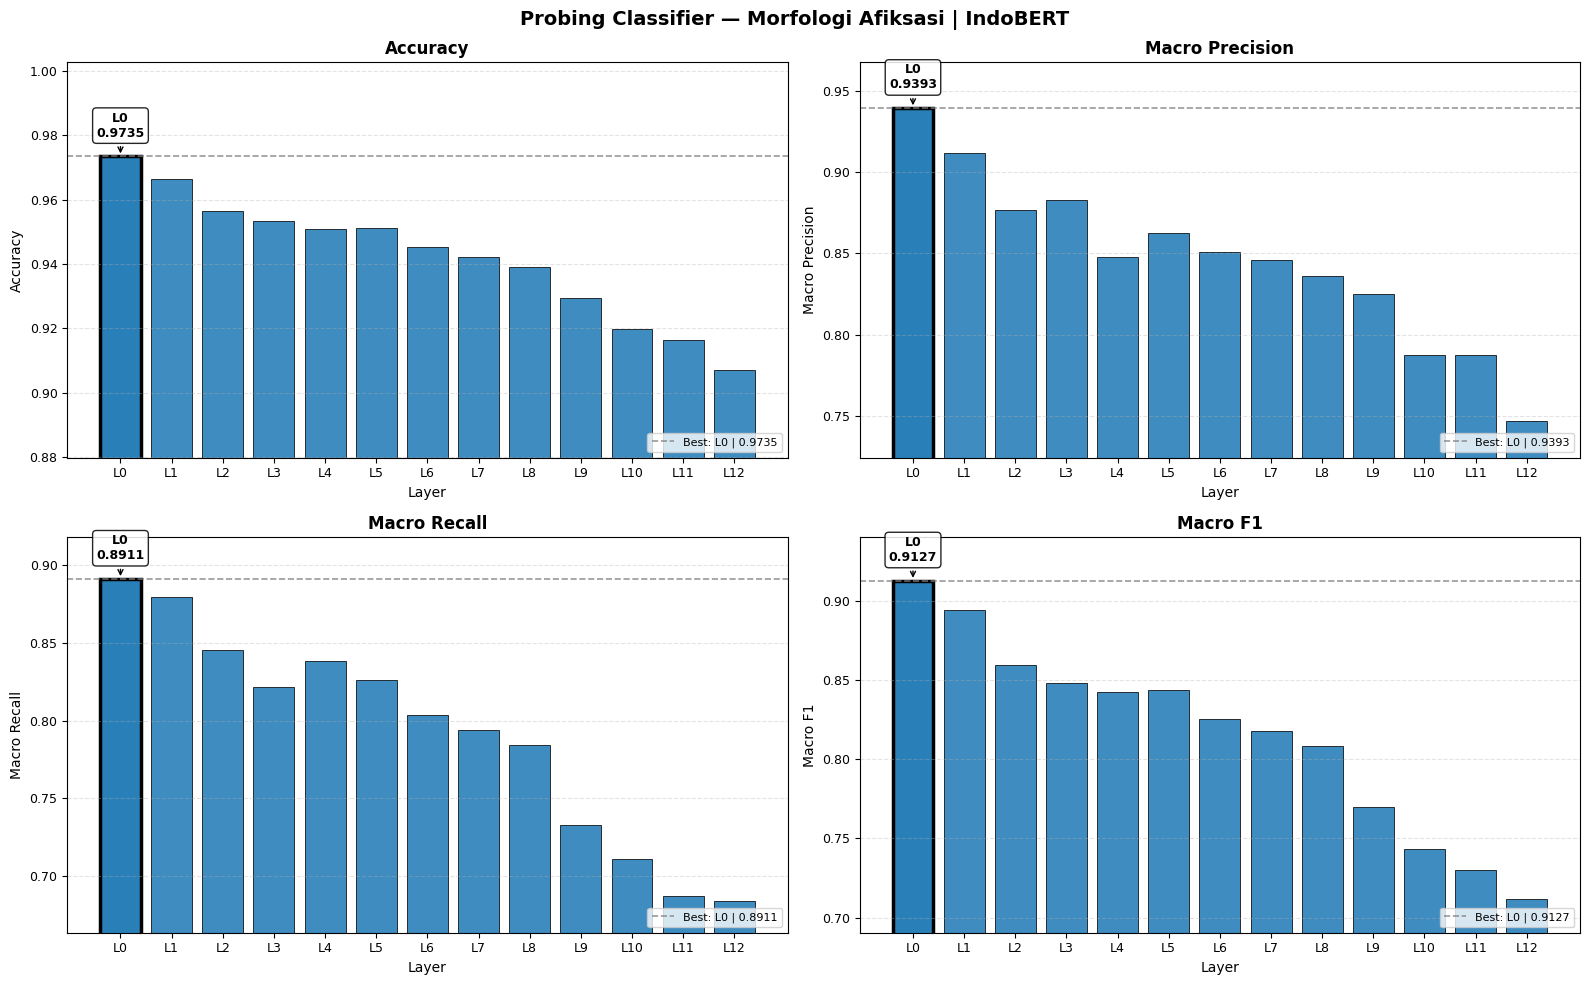

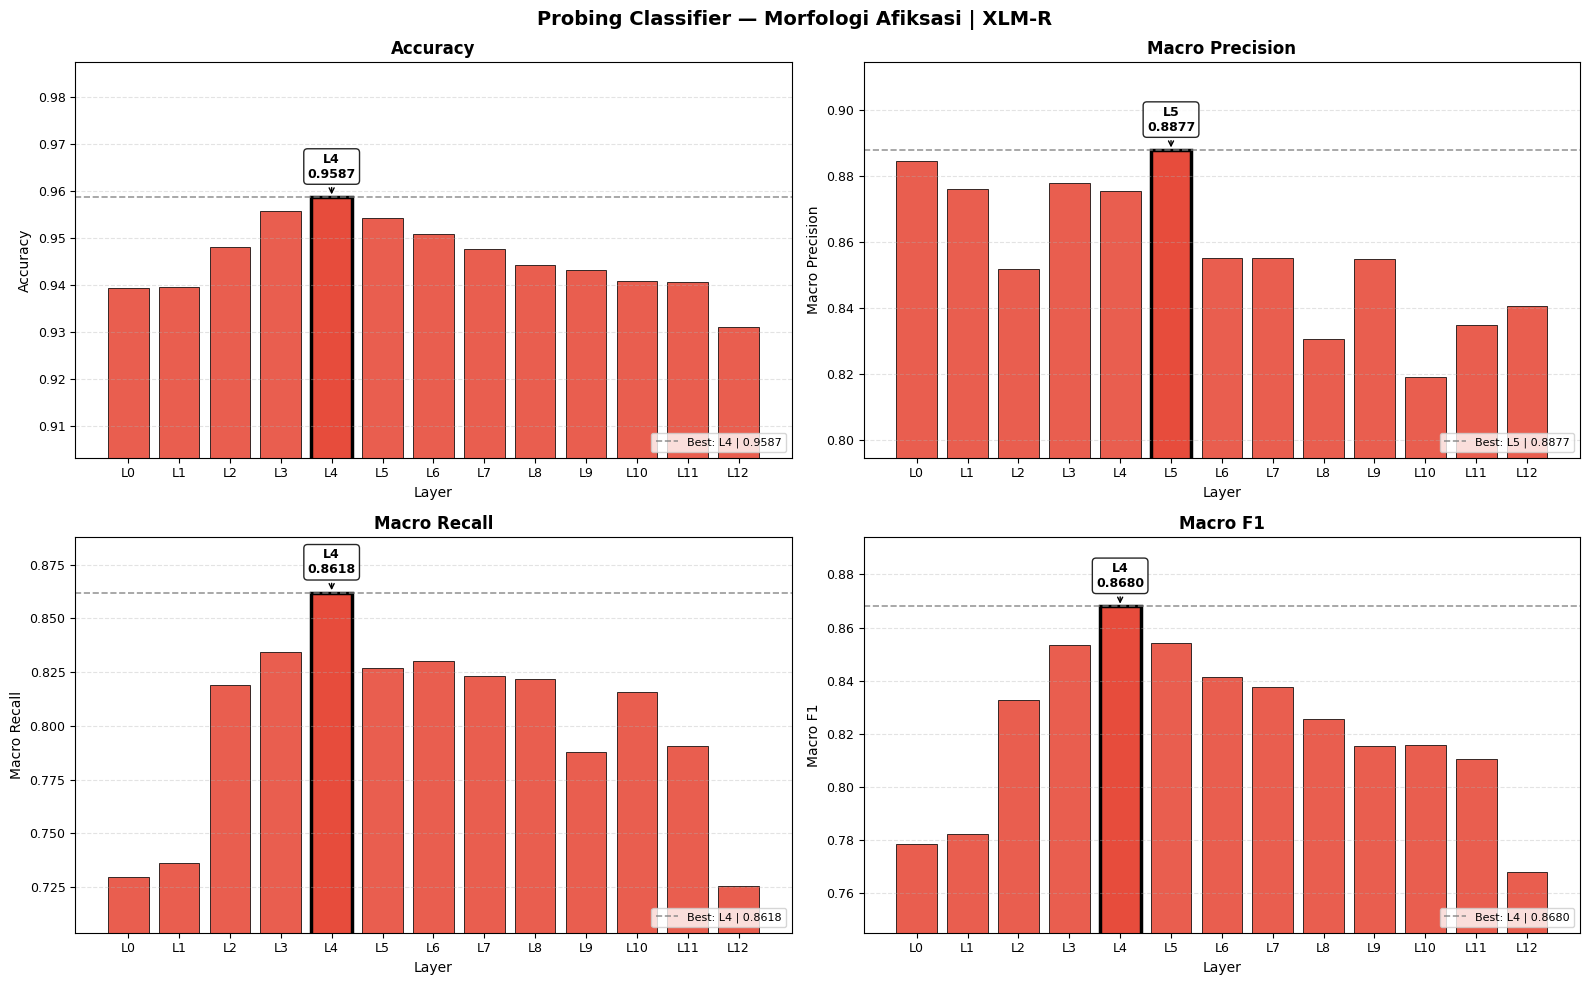

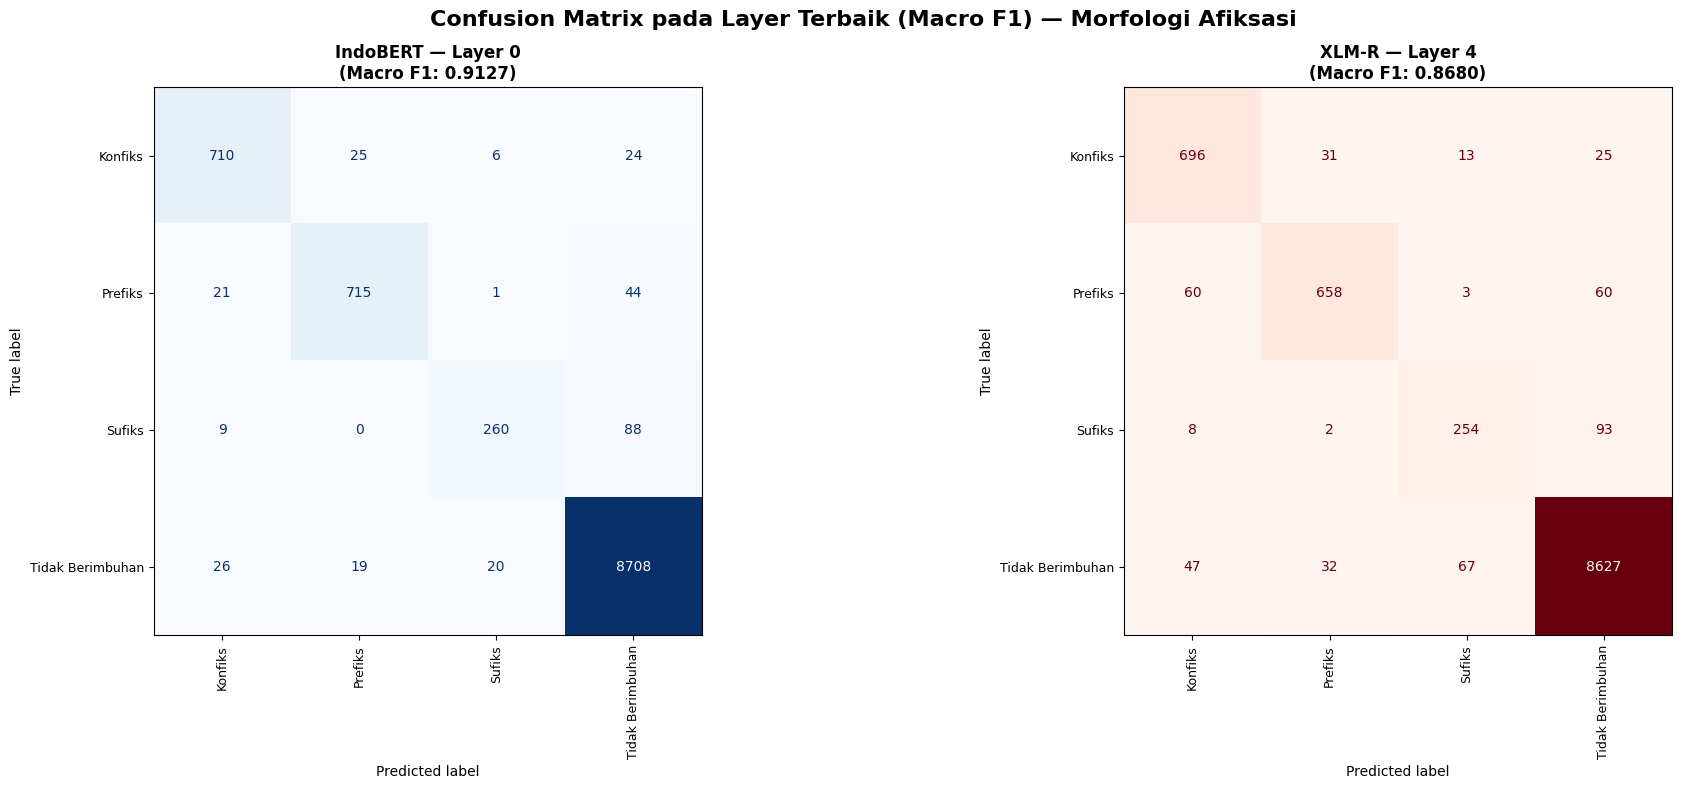

In [23]:
# ── Fungsi Evaluasi ────────────────────────────────────────
def evaluate_probe(model_path, X_eval, y_eval,
                   hidden_size=768, num_classes=4,
                   return_preds=False):
    probe = LinearProbe(hidden_size, num_classes).to(device)
    probe.load_state_dict(
        torch.load(model_path, map_location=device, weights_only=True)
    )
    probe.eval()

    X_ev = torch.tensor(X_eval, dtype=torch.float32).to(device)
    y_ev = torch.tensor(y_eval, dtype=torch.long)

    with torch.no_grad():
        y_pred = probe(X_ev).argmax(dim=1).cpu().numpy()

    y_np = y_ev.numpy()

    acc  = accuracy_score(y_np, y_pred)
    f1   = f1_score(y_np, y_pred, average='macro', zero_division=0)
    prec = precision_score(y_np, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_np, y_pred, average='macro', zero_division=0)

    if return_preds:
        return acc, f1, prec, rec, y_pred

    return acc, f1, prec, rec


# ── Evaluasi per Layer ─────────────────────────────────────
results_morph = {
    'indobert': {'acc': [], 'f1': [], 'precision': [], 'recall': [], 'y_pred': []},
    'xlmr'    : {'acc': [], 'f1': [], 'precision': [], 'recall': [], 'y_pred': []}
}

TERM_W = 85

print("\n" + "=" * TERM_W)
print("EVALUASI PROBING CLASSIFIER PER LAYER — MORFOLOGI AFIKSASI".center(TERM_W))
print("=" * TERM_W)
print(
    f"{'Layer':<7}"
    f"{'IB Acc':>8}{'IB P':>8}{'IB R':>8}{'IB mF1':>8} │ "
    f"{'XLM Acc':>8}{'XLM P':>8}{'XLM R':>8}{'XLM mF1':>8}"
)
print("-" * TERM_W)

for layer_idx in range(NUM_LAYERS):
    row = {}

    for model_key, dir_probe in [
        ("indobert", DIR_PROBE_IB),
        ("xlmr",     DIR_PROBE_XLM)
    ]:
        _, X_dev_layer = load_layer_X(model_key, layer_idx)
        model_path = os.path.join(dir_probe, f"probe_L{layer_idx}.pt")

        acc, f1, prec, rec, y_pred = evaluate_probe(
            model_path,
            X_dev_layer,
            y_dev,
            hidden_size=HIDDEN_SIZE,
            num_classes=NUM_CLASSES,
            return_preds=True
        )

        del X_dev_layer
        gc.collect()

        results_morph[model_key]['acc'].append(acc)
        results_morph[model_key]['f1'].append(f1)
        results_morph[model_key]['precision'].append(prec)
        results_morph[model_key]['recall'].append(rec)
        results_morph[model_key]['y_pred'].append(y_pred)

        row[model_key] = (acc, prec, rec, f1)

    acc_i, prec_i, rec_i, f1_i = row['indobert']
    acc_x, prec_x, rec_x, f1_x = row['xlmr']

    print(
        f"L{layer_idx:<6}"
        f"{acc_i:>8.4f}{prec_i:>8.4f}{rec_i:>8.4f}{f1_i:>8.4f} │ "
        f"{acc_x:>8.4f}{prec_x:>8.4f}{rec_x:>8.4f}{f1_x:>8.4f}"
    )

print("=" * TERM_W)


# ── Indeks Layer Terbaik untuk Setiap Metrik ───────────────
best_morph = {
    model: {
        metric: int(np.argmax(results_morph[model][metric]))
        for metric in ['acc', 'f1', 'precision', 'recall']
    }
    for model in ['indobert', 'xlmr']
}


# ── Ringkasan Best Layer — Terminal Style Seragam ──────────
METRICS = [
    ('acc',       'Acc'),
    ('precision', 'Prec'),
    ('recall',    'Rec'),
    ('f1',        'mF1')
]

best_ib_row  = best_morph['indobert']['f1']
best_xlm_row = best_morph['xlmr']['f1']
best_layers_to_show = sorted(set([best_ib_row, best_xlm_row]))

print("\n" + "=" * TERM_W)
print("RINGKASAN BEST LAYER PROBING CLASSIFIER — MORFOLOGI AFIKSASI".center(TERM_W))
print("=" * TERM_W)
print("Best layer ditentukan berdasarkan Macro F1".center(TERM_W))
print("-" * TERM_W)

print(
    f"{'':7}"
    f"{'── IndoBERT ──':^32} │ "
    f"{'── XLM-R ──':^32} {'Best':>8}"
)

print(
    f"{'Layer':<7}"
    f"{'Acc':>8}{'Prec':>8}{'Rec':>8}{'mF1':>8} │ "
    f"{'Acc':>8}{'Prec':>8}{'Rec':>8}{'mF1':>8} {'':>8}"
)

print("-" * TERM_W)

for i in best_layers_to_show:
    ib_vals = "".join(
        f"{results_morph['indobert'][metric][i]:>8.4f}"
        for metric, _ in METRICS
    )

    xlm_vals = "".join(
        f"{results_morph['xlmr'][metric][i]:>8.4f}"
        for metric, _ in METRICS
    )

    best_tag = []
    if i == best_ib_row:
        best_tag.append("IB")
    if i == best_xlm_row:
        best_tag.append("XLM")

    best_tag = " + ".join(best_tag)

    print(
        f"L{i:<6}"
        f"{ib_vals} │ "
        f"{xlm_vals} {best_tag:>8}"
    )

print("=" * TERM_W)


# ── Visualisasi Bar Chart — Clean dan Informatif ───────────
layer_ticks = [f"L{i}" for i in range(NUM_LAYERS)]

metrics_plot = [
    ('acc',       'Accuracy'),
    ('precision', 'Macro Precision'),
    ('recall',    'Macro Recall'),
    ('f1',        'Macro F1'),
]


# ── Bar Chart IndoBERT ─────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(
    'Probing Classifier — Morfologi Afiksasi | IndoBERT',
    fontsize=14,
    fontweight='bold'
)

axes = axes.flatten()

for ax, (metric, title) in zip(axes, metrics_plot):
    values = results_morph['indobert'][metric]
    best_layer = best_morph['indobert'][metric]
    best_val = values[best_layer]

    min_val = min(values)
    max_val = max(values)

    y_min = min_val * 0.97
    y_max = max_val * 1.03

    bars = ax.bar(
        layer_ticks,
        values,
        color='#2980b9',
        edgecolor='black',
        linewidth=0.6,
        alpha=0.9
    )

    bars[best_layer].set_edgecolor('black')
    bars[best_layer].set_linewidth(2.5)
    bars[best_layer].set_alpha(1.0)

    ax.axhline(
        best_val,
        linestyle='--',
        linewidth=1.2,
        color='gray',
        alpha=0.8,
        label=f'Best: L{best_layer} | {best_val:.4f}'
    )

    ax.annotate(
        f"L{best_layer}\n{best_val:.4f}",
        xy=(best_layer, best_val),
        xytext=(0, 12),
        textcoords='offset points',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold',
        bbox=dict(
            boxstyle='round,pad=0.3',
            fc='white',
            ec='black',
            alpha=0.85
        ),
        arrowprops=dict(
            arrowstyle='->',
            color='black',
            linewidth=1
        )
    )

    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Layer')
    ax.set_ylabel(title)
    ax.set_ylim(y_min, y_max)
    ax.grid(True, axis='y', linestyle='--', alpha=0.35)
    ax.legend(fontsize=8, loc='lower right')
    ax.tick_params(axis='x', rotation=0)
    ax.tick_params(axis='both', labelsize=9)

plt.tight_layout()
plt.show()


# ── Bar Chart XLM-R ────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(
    'Probing Classifier — Morfologi Afiksasi | XLM-R',
    fontsize=14,
    fontweight='bold'
)

axes = axes.flatten()

for ax, (metric, title) in zip(axes, metrics_plot):
    values = results_morph['xlmr'][metric]
    best_layer = best_morph['xlmr'][metric]
    best_val = values[best_layer]

    min_val = min(values)
    max_val = max(values)

    y_min = min_val * 0.97
    y_max = max_val * 1.03

    bars = ax.bar(
        layer_ticks,
        values,
        color='#e74c3c',
        edgecolor='black',
        linewidth=0.6,
        alpha=0.9
    )

    bars[best_layer].set_edgecolor('black')
    bars[best_layer].set_linewidth(2.5)
    bars[best_layer].set_alpha(1.0)

    ax.axhline(
        best_val,
        linestyle='--',
        linewidth=1.2,
        color='gray',
        alpha=0.8,
        label=f'Best: L{best_layer} | {best_val:.4f}'
    )

    ax.annotate(
        f"L{best_layer}\n{best_val:.4f}",
        xy=(best_layer, best_val),
        xytext=(0, 12),
        textcoords='offset points',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold',
        bbox=dict(
            boxstyle='round,pad=0.3',
            fc='white',
            ec='black',
            alpha=0.85
        ),
        arrowprops=dict(
            arrowstyle='->',
            color='black',
            linewidth=1
        )
    )

    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Layer')
    ax.set_ylabel(title)
    ax.set_ylim(y_min, y_max)
    ax.grid(True, axis='y', linestyle='--', alpha=0.35)
    ax.legend(fontsize=8, loc='lower right')
    ax.tick_params(axis='x', rotation=0)
    ax.tick_params(axis='both', labelsize=9)

plt.tight_layout()
plt.show()


# ── Confusion Matrix pada Layer Terbaik Macro F1 ───────────
CLASS_NAMES = list(label_encoder.classes_)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle(
    'Confusion Matrix pada Layer Terbaik (Macro F1) — Morfologi Afiksasi',
    fontsize=16,
    fontweight='bold'
)

for ax, model_key, model_name, color in zip(
    axes,
    ['indobert', 'xlmr'],
    ['IndoBERT', 'XLM-R'],
    ['Blues', 'Reds']
):
    best_layer = best_morph[model_key]['f1']
    best_f1 = results_morph[model_key]['f1'][best_layer]

    cm = confusion_matrix(
        y_dev,
        results_morph[model_key]['y_pred'][best_layer]
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=CLASS_NAMES
    )

    disp.plot(
        ax=ax,
        colorbar=False,
        cmap=color,
        xticks_rotation=90
    )

    ax.set_title(
        f'{model_name} — Layer {best_layer}\n'
        f'(Macro F1: {best_f1:.4f})',
        fontweight='bold'
    )

    ax.tick_params(axis='both', which='major', labelsize=9)

plt.tight_layout()
plt.show()

### 7. Analisis Geometris: Center Kernel Alignment (CKA) - Similarity

CKA mengukur kemiripan representasi antar layer / antar model.
<br>Nilai 1.0 = identik | Nilai 0.0 = sama sekali berbeda

Menghitung CKA internal IndoBERT...
Menghitung CKA internal XLM-R...
Menghitung CKA cross-model per layer...


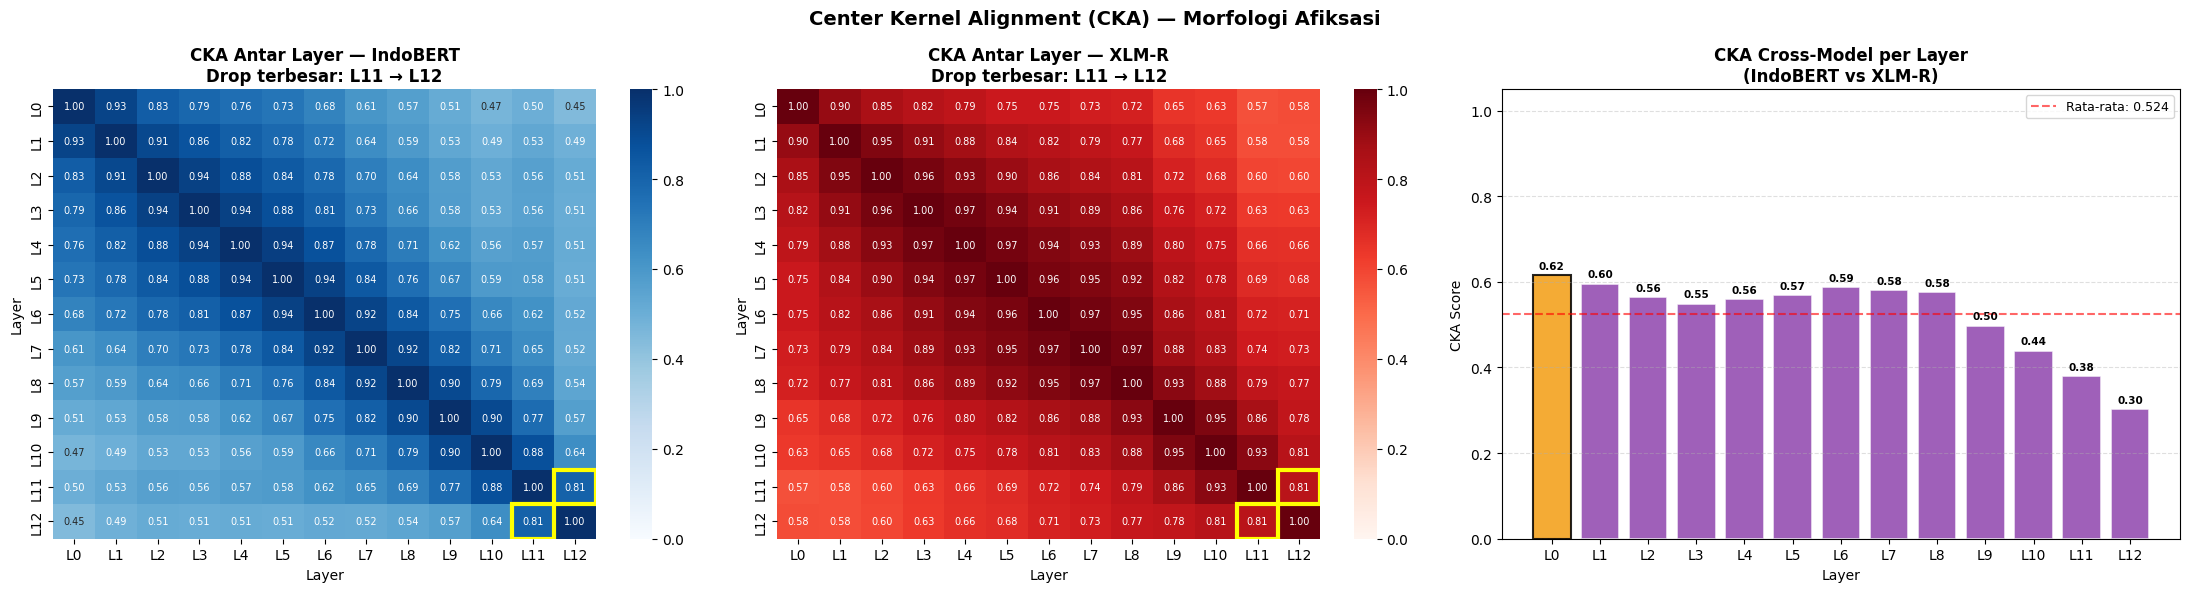

In [ ]:
# ============================================================
# TAHAP 7: CENTER KERNEL ALIGNMENT (CKA)
# Visual clean + highlight sequential drop terbesar
# ============================================================

# ------------------------------------------------------------
# 1) FUNGSI CKA
# ------------------------------------------------------------

def centering(K):
    n = K.shape[0]
    H = np.eye(n) - np.ones((n, n)) / n
    return H @ K @ H

def linear_cka(X, Y):
    K = centering(X @ X.T)
    L = centering(Y @ Y.T)
    num = np.sum(K * L)
    den = np.sqrt(np.sum(K * K)) * np.sqrt(np.sum(L * L))
    return float(num / den) if den > 0 else 0.0

def compute_cka_matrix(X_layers):
    n = X_layers.shape[1]
    M = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            M[i, j] = linear_cka(X_layers[:, i, :], X_layers[:, j, :])
    return M


# ------------------------------------------------------------
# 2) HIGHLIGHT SEQUENTIAL DROP TERBESAR
# ------------------------------------------------------------

def highlight_sequential_max(ax, cka_matrix):
    """
    Highlight pasangan layer berurutan dengan drop terbesar.
    """
    n = cka_matrix.shape[0]

    seq_cka = np.array([cka_matrix[i, i+1] for i in range(n-1)])
    seq_drop = 1 - seq_cka

    best_idx = int(np.argmax(seq_drop))

    # kotak highlight (dua arah karena matriks simetris)
    rect1 = plt.Rectangle((best_idx+1, best_idx), 1, 1,
                          fill=False, edgecolor='yellow', linewidth=3)
    rect2 = plt.Rectangle((best_idx, best_idx+1), 1, 1,
                          fill=False, edgecolor='yellow', linewidth=3)

    ax.add_patch(rect1)
    ax.add_patch(rect2)

    return best_idx, seq_cka, seq_drop


# ------------------------------------------------------------
# 3) SAMPLING DATA
# ------------------------------------------------------------

layer_ticks = [f"L{i}" for i in range(NUM_LAYERS)]

MAX_CKA = 1000
idx_cka = np.random.choice(
    len(X_test_indobert),
    size=min(MAX_CKA, len(X_test_indobert)),
    replace=False
)

X_cka_ib  = X_test_indobert[idx_cka]
X_cka_xlm = X_test_xlmr[idx_cka]


# ------------------------------------------------------------
# 4) HITUNG CKA
# ------------------------------------------------------------

print("Menghitung CKA internal IndoBERT...")
cka_ib = compute_cka_matrix(X_cka_ib)

print("Menghitung CKA internal XLM-R...")
cka_xlm = compute_cka_matrix(X_cka_xlm)

print("Menghitung CKA cross-model per layer...")
cka_cross = np.array([
    linear_cka(X_cka_ib[:, i, :], X_cka_xlm[:, i, :])
    for i in range(NUM_LAYERS)
])


# ------------------------------------------------------------
# 5) VISUALISASI
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle('Center Kernel Alignment (CKA) — Morfologi Afiksasi',
             fontsize=14, fontweight='bold')

# ── Heatmap IndoBERT ────────────────────────────────────────
sns.heatmap(
    cka_ib,
    ax=axes[0],
    xticklabels=layer_ticks,
    yticklabels=layer_ticks,
    vmin=0, vmax=1,
    cmap='Blues',
    annot=True,
    fmt='.2f',
    annot_kws={'size': 7}
)

best_ib_idx, seq_cka_ib, seq_drop_ib = highlight_sequential_max(axes[0], cka_ib)

axes[0].set_title(
    f'CKA Antar Layer — IndoBERT\nDrop terbesar: L{best_ib_idx} → L{best_ib_idx+1}',
    fontweight='bold'
)
axes[0].set_xlabel('Layer')
axes[0].set_ylabel('Layer')


# ── Heatmap XLM-R ───────────────────────────────────────────
sns.heatmap(
    cka_xlm,
    ax=axes[1],
    xticklabels=layer_ticks,
    yticklabels=layer_ticks,
    vmin=0, vmax=1,
    cmap='Reds',
    annot=True,
    fmt='.2f',
    annot_kws={'size': 7}
)

best_xlm_idx, seq_cka_xlm, seq_drop_xlm = highlight_sequential_max(axes[1], cka_xlm)

axes[1].set_title(
    f'CKA Antar Layer — XLM-R\nDrop terbesar: L{best_xlm_idx} → L{best_xlm_idx+1}',
    fontweight='bold'
)
axes[1].set_xlabel('Layer')
axes[1].set_ylabel('Layer')


# ── Cross-model Bar Chart ───────────────────────────────────
bars = axes[2].bar(
    layer_ticks,
    cka_cross,
    color='#8e44ad',
    alpha=0.85,
    edgecolor='white',
    linewidth=1.2
)

best_cross = int(np.argmax(cka_cross))

bars[best_cross].set_color('#f39c12')
bars[best_cross].set_edgecolor('black')
bars[best_cross].set_linewidth(1.5)

axes[2].set_title('CKA Cross-Model per Layer\n(IndoBERT vs XLM-R)',
                  fontweight='bold')
axes[2].set_xlabel('Layer')
axes[2].set_ylabel('CKA Score')
axes[2].set_ylim(0, 1.05)

axes[2].axhline(
    y=np.mean(cka_cross),
    color='red',
    linestyle='--',
    alpha=0.6,
    label=f'Rata-rata: {np.mean(cka_cross):.3f}'
)

axes[2].legend(fontsize=9)
axes[2].grid(True, linestyle='--', alpha=0.4, axis='y')

for i, val in enumerate(cka_cross):
    axes[2].text(i, val + 0.01, f'{val:.2f}',
                 ha='center', va='bottom',
                 fontsize=7.5, fontweight='bold')

plt.tight_layout()
plt.show()

## B. POS Tagging (Syntactic)

### 1. Load Dataset dan Encode Label Target

In [30]:
# ============================================================
# TAHAP 1: LOAD DATASET POS TAGGING
# ============================================================

BASE_PROCESSED = r"D:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\data\processed\POS_Tagging"

df_train_raw = pd.read_csv(os.path.join(BASE_PROCESSED, "indolem_train_pos.csv"))
df_dev_raw   = pd.read_csv(os.path.join(BASE_PROCESSED, "indolem_dev_pos.csv"))
df_test_raw  = pd.read_csv(os.path.join(BASE_PROCESSED, "indolem_test_pos.csv"))

COLS_X = ['sent_id', 'token_id', 'token']
COLS_Y = 'pos_tag'

df_train = df_train_raw[COLS_X + [COLS_Y]].dropna().copy()
df_dev   = df_dev_raw[COLS_X + [COLS_Y]].dropna().copy()
df_test  = df_test_raw[COLS_X + [COLS_Y]].dropna().copy()

# Encode label
label_encoder = LabelEncoder()
label_encoder.fit(df_train[COLS_Y])

y_train = label_encoder.transform(df_train[COLS_Y])
y_dev   = label_encoder.transform(df_dev[COLS_Y])
y_test  = label_encoder.transform(df_test[COLS_Y])

df_train['label_encoded'] = y_train
df_dev['label_encoded']   = y_dev
df_test['label_encoded']  = y_test

NUM_CLASSES = len(label_encoder.classes_)
NUM_LAYERS  = 13    # layer-0 (embedding) + layer 1–12 (transformer)
HIDDEN_SIZE = 768

print("=" * 55)
print("INFO DATASET POS TAGGING")
print("=" * 55)
print(f"Kolom X : {COLS_X}")
print(f"Kolom Y : {COLS_Y}")
print(f"Jumlah Kelas : {NUM_CLASSES}")
print(f"Train   : {len(df_train):,} token")
print(f"Dev     : {len(df_dev):,} token")
print(f"Test    : {len(df_test):,} token")

INFO DATASET POS TAGGING
Kolom X : ['sent_id', 'token_id', 'token']
Kolom Y : pos_tag
Jumlah Kelas : 23
Train   : 942,214 token
Dev     : 105,274 token
Test    : 261,872 token


### 2. Ekstraksi Hidden States

Yang dilakukan:
1. Mengekstrak hidden states semua layer untuk setiap token

Input:
1. df: DataFrame dengan kolom [sent_id, token_id, token, pos_tag]
2. tokenizer, model : model HuggingFace yang sudah di-load

Output:
1. np.array shape (total_token, num_layer, hidden_size) | misal: (9232, 13, 768)
2. Layer 0     = embedding statis (non-contextual)
3. Layer 1–12  = transformer layers (contextual)

In [31]:
# ============================================================
# TAHAP 2: FUNGSI EKSTRAKSI HIDDEN STATES
# ============================================================

def extract_hidden_states(df, tokenizer, model, device, desc="Ekstraksi"):
    model.eval()
    all_hidden  = []
    all_labels  = []
    skipped_cnt = 0

    # Groupby sent_id, sort token berdasarkan token_id
    grouped = df.groupby('sent_id', sort=False)

    for sent_id, group in tqdm(grouped, desc=desc):
        group  = group.sort_values('token_id')
        tokens = group['token'].tolist()
        labels = group['label_encoded'].tolist()

        # Tokenisasi — is_split_into_words=True karena input sudah list kata
        # Satu kata bisa dipecah jadi beberapa subword oleh tokenizer
        encoding = tokenizer(
            tokens,
            is_split_into_words = True,
            return_tensors      = "pt",
            padding             = True,
            truncation          = True,
            max_length          = 512
        )

        input_ids      = encoding['input_ids'].to(device)
        attention_mask = encoding['attention_mask'].to(device)

        with torch.no_grad():
            outputs = model(
                input_ids      = input_ids,
                attention_mask = attention_mask
            )

        hidden_states = outputs.hidden_states

        # ── Mapping subword → token asli ──────────────────────────
        # word_ids() mengembalikan list index kata asli untuk tiap subword
        # Contoh: "membangun" → ["mem", "##bangun"]
        #   word_ids = [None, 0, 0, 0, 1, 1, 2, None]
        #              [CLS] [mem][##b][##u][tok1][tok2] [SEP]
        # Strategi: ambil subword PERTAMA sebagai representasi kata
        word_ids = encoding.word_ids(batch_index=0)

        first_subword_pos = {}
        for pos, word_idx in enumerate(word_ids):
            if word_idx is not None and word_idx not in first_subword_pos:
                first_subword_pos[word_idx] = pos

        for word_idx in range(len(tokens)):
            if word_idx not in first_subword_pos:
                skipped_cnt += 1
                continue

            pos = first_subword_pos[word_idx]

            token_repr = np.array([
                hidden_states[layer_idx][0, pos, :].cpu().numpy()
                for layer_idx in range(len(hidden_states))
            ])

            all_hidden.append(token_repr)
            all_labels.append(labels[word_idx])

    if skipped_cnt > 0:
        print(f"  ⚠ {skipped_cnt} token dilewati akibat truncation (max_length=512)")

    return np.array(all_hidden), np.array(all_labels) 

### 3. Eksekusi Ekstraksi: IndoBERT

Direktori Hidden States POS Tagging:

In [32]:
SAVE_DIR = r"D:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\notebook\Ekstraksi_Hidden_States\POS_Tagging"
os.makedirs(SAVE_DIR, exist_ok=True)

Ekstraksi IndoBERT:

In [ ]:
# ============================================================
# TAHAP 3: EKSTRAKSI FITUR (INDOBERT) & SIMPAN PER LAYER
# ============================================================

print("=" * 65)
print("EKSTRAKSI HIDDEN STATES — IndoBERT")
print("=" * 65)

# ── 1. Ekstrak & Simpan Dev Set (Per Layer) ──────────────────────────────
print("\n[1/3] Memproses Dev Set...")
X_dev, y_dev = extract_hidden_states(
    df_dev, tokenizer_indobert, model_indobert, device, "IndoBERT | Dev  ")

print("Menyimpan Dev Set per Layer...")
for i in range(NUM_LAYERS):
    # Ambil semua token, HANYA pada layer ke-i, semua hidden size (768)
    X_layer = X_dev[:, i, :].astype(np.float16) 
    np.savez_compressed(os.path.join(SAVE_DIR, f"indobert_pos_dev_L{i}.npz"), X=X_layer, y=y_dev)

del X_dev, y_dev, X_layer
gc.collect() # Bersihkan RAM
print("✅ Dev Set (13 Layer) tersimpan!")


# ── 2. Ekstrak & Simpan Test Set (Per Layer) ──────────────────────────────
print("\n[2/3] Memproses Test Set...")
X_test, y_test = extract_hidden_states(
    df_test, tokenizer_indobert, model_indobert, device, "IndoBERT | Test ")

print("Menyimpan Test Set per Layer...")
for i in range(NUM_LAYERS):
    X_layer = X_test[:, i, :].astype(np.float16)
    np.savez_compressed(os.path.join(SAVE_DIR, f"indobert_pos_test_L{i}.npz"), X=X_layer, y=y_test)

del X_test, y_test, X_layer
gc.collect()
print("✅ Test Set (13 Layer) tersimpan!")


# ── 3. Ekstrak & Simpan Train Set (Chunking + Per Layer) ──────────────────
print("\n[3/3] Memproses Train Set (Dipecah 3 bagian)...")
num_chunks = 3
chunk_size = len(df_train) // num_chunks

for c in range(num_chunks):
    print(f"\n   -> Ekstraksi Train Part {c+1}/{num_chunks}...")
    start_idx = c * chunk_size
    end_idx = len(df_train) if c == num_chunks - 1 else (c + 1) * chunk_size
    
    df_chunk = df_train.iloc[start_idx:end_idx]
    X_chunk, y_chunk = extract_hidden_states(
        df_chunk, tokenizer_indobert, model_indobert, device, f"Train P-{c+1}"
    )
    
    print(f"   -> Menyimpan Train Part {c+1} per Layer...")
    for i in range(NUM_LAYERS):
        X_layer = X_chunk[:, i, :].astype(np.float16)
        np.savez_compressed(os.path.join(SAVE_DIR, f"indobert_pos_train_part{c+1}_L{i}.npz"), X=X_layer, y=y_chunk)
        
    del X_chunk, y_chunk, X_layer
    gc.collect()
    print(f"   ✅ Train Part {c+1} (13 Layer) tersimpan!")

print(f"\n🎉 Selesai! Semua file tersimpan per-layer di: {SAVE_DIR}")

EKSTRAKSI HIDDEN STATES — IndoBERT

[1/3] Memproses Dev Set...


IndoBERT | Dev  : 100%|██████████| 4010/4010 [02:38<00:00, 25.31it/s]


Menyimpan Dev Set per Layer...
✅ Dev Set (13 Layer) tersimpan!

[2/3] Memproses Test Set...


IndoBERT | Test : 100%|██████████| 10030/10030 [06:07<00:00, 27.27it/s]


Menyimpan Test Set per Layer...
✅ Test Set (13 Layer) tersimpan!

[3/3] Memproses Train Set (Dipecah 3 bagian)...

   -> Ekstraksi Train Part 1/3...


...

   -> Menyimpan Train Part 1 per Layer...
   ✅ Train Part 1 (13 Layer) tersimpan!

   -> Ekstraksi Train Part 2/3...


Train P-2: 100%|██████████| 12034/12034 [07:33<00:00, 26.54it/s]


   -> Menyimpan Train Part 2 per Layer...
   ✅ Train Part 2 (13 Layer) tersimpan!

   -> Ekstraksi Train Part 3/3...


Train P-3: 100%|██████████| 12029/12029 [07:19<00:00, 27.35it/s]


   -> Menyimpan Train Part 3 per Layer...
   ✅ Train Part 3 (13 Layer) tersimpan!

🎉 Selesai! Semua file tersimpan per-layer di: D:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\notebook\Ekstraksi_Hidden_States\POS_Tagging


### 4. Eksekusi Ekstraksi: XLM-R

In [ ]:
# ============================================================
# TAHAP 4: EKSTRAKSI FITUR (XLM-R) & SIMPAN PER LAYER
# ============================================================

print("\n" + "=" * 65)
print("EKSTRAKSI HIDDEN STATES — XLM-R")
print("=" * 65)

# ── 1. Ekstrak & Simpan Dev Set (Per Layer) ──────────────────────────────
print("\n[1/3] Memproses Dev Set (XLM-R)...")
X_dev, y_dev = extract_hidden_states(
    df_dev, tokenizer_xlmr, model_xlmr, device, "XLM-R   | Dev  ")

print("Menyimpan Dev Set XLM-R per Layer...")
for i in range(NUM_LAYERS):
    X_layer = X_dev[:, i, :].astype(np.float16) # Ubah ke float16
    np.savez_compressed(os.path.join(SAVE_DIR, f"xlmr_pos_dev_L{i}.npz"), X=X_layer, y=y_dev)

del X_dev, y_dev, X_layer
gc.collect() # Bersihkan RAM
print("✅ Dev Set XLM-R (13 Layer) tersimpan!")


# ── 2. Ekstrak & Simpan Test Set (Per Layer) ──────────────────────────────
print("\n[2/3] Memproses Test Set (XLM-R)...")
X_test, y_test = extract_hidden_states(
    df_test, tokenizer_xlmr, model_xlmr, device, "XLM-R   | Test ")

print("Menyimpan Test Set XLM-R per Layer...")
for i in range(NUM_LAYERS):
    X_layer = X_test[:, i, :].astype(np.float16)
    np.savez_compressed(os.path.join(SAVE_DIR, f"xlmr_pos_test_L{i}.npz"), X=X_layer, y=y_test)

del X_test, y_test, X_layer
gc.collect()
print("✅ Test Set XLM-R (13 Layer) tersimpan!")


# ── 3. Ekstrak & Simpan Train Set (Chunking + Per Layer) ──────────────────
print("\n[3/3] Memproses Train Set XLM-R (Dipecah 3 bagian)...")
num_chunks = 3
chunk_size = len(df_train) // num_chunks

for c in range(num_chunks):
    print(f"\n   -> Ekstraksi Train Part {c+1}/{num_chunks}...")
    start_idx = c * chunk_size
    end_idx = len(df_train) if c == num_chunks - 1 else (c + 1) * chunk_size
    
    df_chunk = df_train.iloc[start_idx:end_idx]
    X_chunk, y_chunk = extract_hidden_states(
        df_chunk, tokenizer_xlmr, model_xlmr, device, f"Train P-{c+1}"
    )
    
    print(f"   -> Menyimpan Train Part {c+1} XLM-R per Layer...")
    for i in range(NUM_LAYERS):
        X_layer = X_chunk[:, i, :].astype(np.float16)
        np.savez_compressed(os.path.join(SAVE_DIR, f"xlmr_pos_train_part{c+1}_L{i}.npz"), X=X_layer, y=y_chunk)
        
    del X_chunk, y_chunk, X_layer
    gc.collect()
    print(f"   ✅ Train Part {c+1} XLM-R (13 Layer) tersimpan!")

print(f"\n🎉 Selesai! Semua file XLM-R tersimpan per-layer di: {SAVE_DIR}")


EKSTRAKSI HIDDEN STATES — XLM-R

[1/3] Memproses Dev Set (XLM-R)...


XLM-R   | Dev  : 100%|██████████| 4010/4010 [02:32<00:00, 26.36it/s]


Menyimpan Dev Set XLM-R per Layer...
✅ Dev Set XLM-R (13 Layer) tersimpan!

[2/3] Memproses Test Set (XLM-R)...


XLM-R   | Test : 100%|██████████| 10030/10030 [07:19<00:00, 22.80it/s]


Menyimpan Test Set XLM-R per Layer...
✅ Test Set XLM-R (13 Layer) tersimpan!

[3/3] Memproses Train Set XLM-R (Dipecah 3 bagian)...

   -> Ekstraksi Train Part 1/3...


...

   -> Menyimpan Train Part 1 XLM-R per Layer...
   ✅ Train Part 1 XLM-R (13 Layer) tersimpan!

   -> Ekstraksi Train Part 2/3...


Train P-2: 100%|██████████| 12034/12034 [08:38<00:00, 23.19it/s]


   -> Menyimpan Train Part 2 XLM-R per Layer...
   ✅ Train Part 2 XLM-R (13 Layer) tersimpan!

   -> Ekstraksi Train Part 3/3...


Train P-3: 100%|██████████| 12029/12029 [08:41<00:00, 23.08it/s]


   -> Menyimpan Train Part 3 XLM-R per Layer...
   ✅ Train Part 3 XLM-R (13 Layer) tersimpan!

🎉 Selesai! Semua file XLM-R tersimpan per-layer di: D:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\notebook\Ekstraksi_Hidden_States\POS_Tagging


### 5. Load Hasil Ekstraksi Hidden States

In [33]:
# ===========================================
# TAHAP 5: LOAD HASIL EKSTRAKSI HIDDEN STATES
# ===========================================

SAVE_DIR = r"D:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\notebook\Ekstraksi_Hidden_States\POS_Tagging"

print("Memuat Labels (y) dari file...")

# Ambil label y dari salah satu file L0 IndoBERT (karena label y selalu sama untuk L0-L12 dan untuk XLM-R)
tmp_dev = np.load(os.path.join(SAVE_DIR, "indobert_pos_dev_L0.npz"))
y_dev = tmp_dev['y']

tmp_test = np.load(os.path.join(SAVE_DIR, "indobert_pos_test_L0.npz"))
y_test = tmp_test['y']

# Untuk Train, karena kita pecah menjadi 3 part, kita harus menggabungkan labelnya
y_train_parts = []
for c in range(1, 4): # Looping part 1, 2, 3
    tmp_train = np.load(os.path.join(SAVE_DIR, f"indobert_pos_train_part{c}_L0.npz"))
    y_train_parts.append(tmp_train['y'])

y_train = np.concatenate(y_train_parts)

print(f"✅ Label Train : {y_train.shape[0]:,} baris")
print(f"✅ Label Dev   : {y_dev.shape[0]:,} baris")
print(f"✅ Label Test  : {y_test.shape[0]:,} baris")
print("ℹ️ Fitur matriks (X) aman di disk dan akan di-load bergantian per-layer pada Tahap 6.")

Memuat Labels (y) dari file...
✅ Label Train : 942,214 baris
✅ Label Dev   : 105,274 baris
✅ Label Test  : 261,872 baris
ℹ️ Fitur matriks (X) aman di disk dan akan di-load bergantian per-layer pada Tahap 6.


### 6. Training Probing Classifier (Linear Classifier - Single Linear Layer)

**Fungsi Pelatihan Probing Classifier**

Step Training: <br>Load Hidden States -> Training Tiap Layer Menggunakan Linear Probe -> Simpan Model Tiap Layer (Yang Berisi Nilai Weight & Bias) Ke Dalam File .pt

In [34]:
# ==============================================================
# TAHAP 6: TRAINING & EVALUASI PROBING CLASSIFIER — POS TAGGING
# ==============================================================

# ── Direktori penyimpanan fitur per layer ────────────────────────────
DIR_PROBE_IB  = r"D:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\notebook\model\POS_Tagging\indobert"
DIR_PROBE_XLM = r"D:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\notebook\model\POS_Tagging\xlmr"

# ── Direktori penyimpanan model ────────────────────────────
DIR_PROBE_POS = r"D:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\notebook\model\POS_Tagging"
os.makedirs(os.path.join(DIR_PROBE_POS, "indobert"), exist_ok=True)
os.makedirs(os.path.join(DIR_PROBE_POS, "xlmr"),     exist_ok=True)

# ── Definisi Probing Classifier ────────────────────────────
class LinearProbe(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.fc = nn.Linear(input_dim, num_classes)

    def forward(self, x):
        return self.fc(x)

# ── Fungsi Load-on-the-fly ─────────────────────────────────
def load_layer_X(model_prefix, layer_idx, num_chunks=3):
    """Meload fitur X hanya untuk layer yang sedang diproses."""
    tmp_dev     = np.load(os.path.join(SAVE_DIR, f"{model_prefix}_pos_dev_L{layer_idx}.npz"))
    X_dev_layer = tmp_dev['X']

    X_train_parts = []
    for c in range(1, num_chunks + 1):
        tmp_train = np.load(os.path.join(SAVE_DIR, f"{model_prefix}_pos_train_part{c}_L{layer_idx}.npz"))
        X_train_parts.append(tmp_train['X'])

    X_train_layer = np.vstack(X_train_parts)
    return X_train_layer, X_dev_layer

# ── Fungsi Training + Simpan ───────────────────────────────
def train_and_save_probe(X_train, y_train,
                         hidden_size=768, num_classes=23,
                         epochs=10, lr=1e-3, batch_size=64,
                         save_path=None):
    """
    Melatih probing classifier untuk satu layer dan
    menyimpan state_dict ke disk (save_path).
    """
    X_tr = torch.tensor(X_train, dtype=torch.float32)
    y_tr = torch.tensor(y_train, dtype=torch.long)

    loader    = DataLoader(TensorDataset(X_tr, y_tr),
                           batch_size=batch_size, shuffle=True)
    probe     = LinearProbe(hidden_size, num_classes).to(device)
    optimizer = optim.Adam(probe.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    for _ in range(epochs):
        probe.train()
        for X_b, y_b in loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            criterion(probe(X_b), y_b).backward()
            optimizer.step()

    if save_path:
        torch.save(probe.state_dict(), save_path)



**Jalankan Training Probing Classifier**

In [35]:
# ── Training per Layer & Simpan Model ──────────────────────
print("=" * 60)
print("  TRAINING & SIMPAN PROBING CLASSIFIER — POS TAGGING")
print("=" * 60)
print(f"  Direktori : {DIR_PROBE_POS}\n")

for layer_idx in range(NUM_LAYERS):
    # IndoBERT
    X_train_ib, _ = load_layer_X("indobert", layer_idx)
    train_and_save_probe(
        X_train_ib, y_train,
        hidden_size=HIDDEN_SIZE, num_classes=NUM_CLASSES,
        save_path=os.path.join(DIR_PROBE_POS, "indobert", f"probe_L{layer_idx}.pt")
    )
    del X_train_ib; gc.collect()

    # XLM-R
    X_train_xlm, _ = load_layer_X("xlmr", layer_idx)
    train_and_save_probe(
        X_train_xlm, y_train,
        hidden_size=HIDDEN_SIZE, num_classes=NUM_CLASSES,
        save_path=os.path.join(DIR_PROBE_POS, "xlmr", f"probe_L{layer_idx}.pt")
    )
    del X_train_xlm; gc.collect()

    print(f"  L{layer_idx:<2} ✅  indobert/probe_L{layer_idx}.pt  &  xlmr/probe_L{layer_idx}.pt")

print(f"\n[SELESAI] Semua model POS Tagging tersimpan di:\n  {DIR_PROBE_POS}")

  TRAINING & SIMPAN PROBING CLASSIFIER — POS TAGGING
  Direktori : D:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\notebook\model\POS_Tagging

  L0  ✅  indobert/probe_L0.pt  &  xlmr/probe_L0.pt
  L1  ✅  indobert/probe_L1.pt  &  xlmr/probe_L1.pt
  L2  ✅  indobert/probe_L2.pt  &  xlmr/probe_L2.pt
  L3  ✅  indobert/probe_L3.pt  &  xlmr/probe_L3.pt
  L4  ✅  indobert/probe_L4.pt  &  xlmr/probe_L4.pt
  L5  ✅  indobert/probe_L5.pt  &  xlmr/probe_L5.pt
  L6  ✅  indobert/probe_L6.pt  &  xlmr/probe_L6.pt
  L7  ✅  indobert/probe_L7.pt  &  xlmr/probe_L7.pt
  L8  ✅  indobert/probe_L8.pt  &  xlmr/probe_L8.pt
  L9  ✅  indobert/probe_L9.pt  &  xlmr/probe_L9.pt
  L10 ✅  indobert/probe_L10.pt  &  xlmr/probe_L10.pt
  L11 ✅  indobert/probe_L11.pt  &  xlmr/probe_L11.pt
  L12 ✅  indobert/probe_L12.pt  &  xlmr/probe_L12.pt

[SELESAI] Semua model POS Tagging tersimpan di:
  D:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\Tu

**Evalusai Hasil Training**

Step Evaluasi: <br>Load Model (Weight & Bias) -> Lakukan Proses Prediksi (Forward Pass) -> Hitung Accuracy / Precision / Recall / Macro F1 -> Tampilkan Dalam Bentuk Grafik


                 EVALUASI PROBING CLASSIFIER PER LAYER — POS TAGGING                 
Layer    IB Acc    IB P    IB R  IB mF1 │  XLM Acc   XLM P   XLM R XLM mF1
-------------------------------------------------------------------------------------
L0       0.9303  0.8841  0.8819  0.8801 │   0.9300  0.8822  0.8657  0.8720
L1       0.9403  0.9086  0.9052  0.9063 │   0.9377  0.9106  0.8663  0.8810
L2       0.9529  0.9206  0.9169  0.9183 │   0.9586  0.9272  0.8856  0.9006
L3       0.9528  0.9222  0.9142  0.9177 │   0.9627  0.9306  0.8967  0.9091
L4       0.9554  0.9238  0.9230  0.9230 │   0.9649  0.9263  0.9229  0.9220
L5       0.9549  0.9212  0.9182  0.9192 │   0.9640  0.8999  0.9193  0.9054
L6       0.9562  0.9178  0.9182  0.9176 │   0.9644  0.9176  0.9152  0.9112
L7       0.9527  0.9089  0.9143  0.9105 │   0.9611  0.9183  0.9187  0.9178
L8       0.9493  0.9162  0.9130  0.9142 │   0.9640  0.9155  0.9204  0.9157
L9       0.9463  0.9113  0.8868  0.8948 │   0.9623  0.9082  0.9147  0.9093
L1

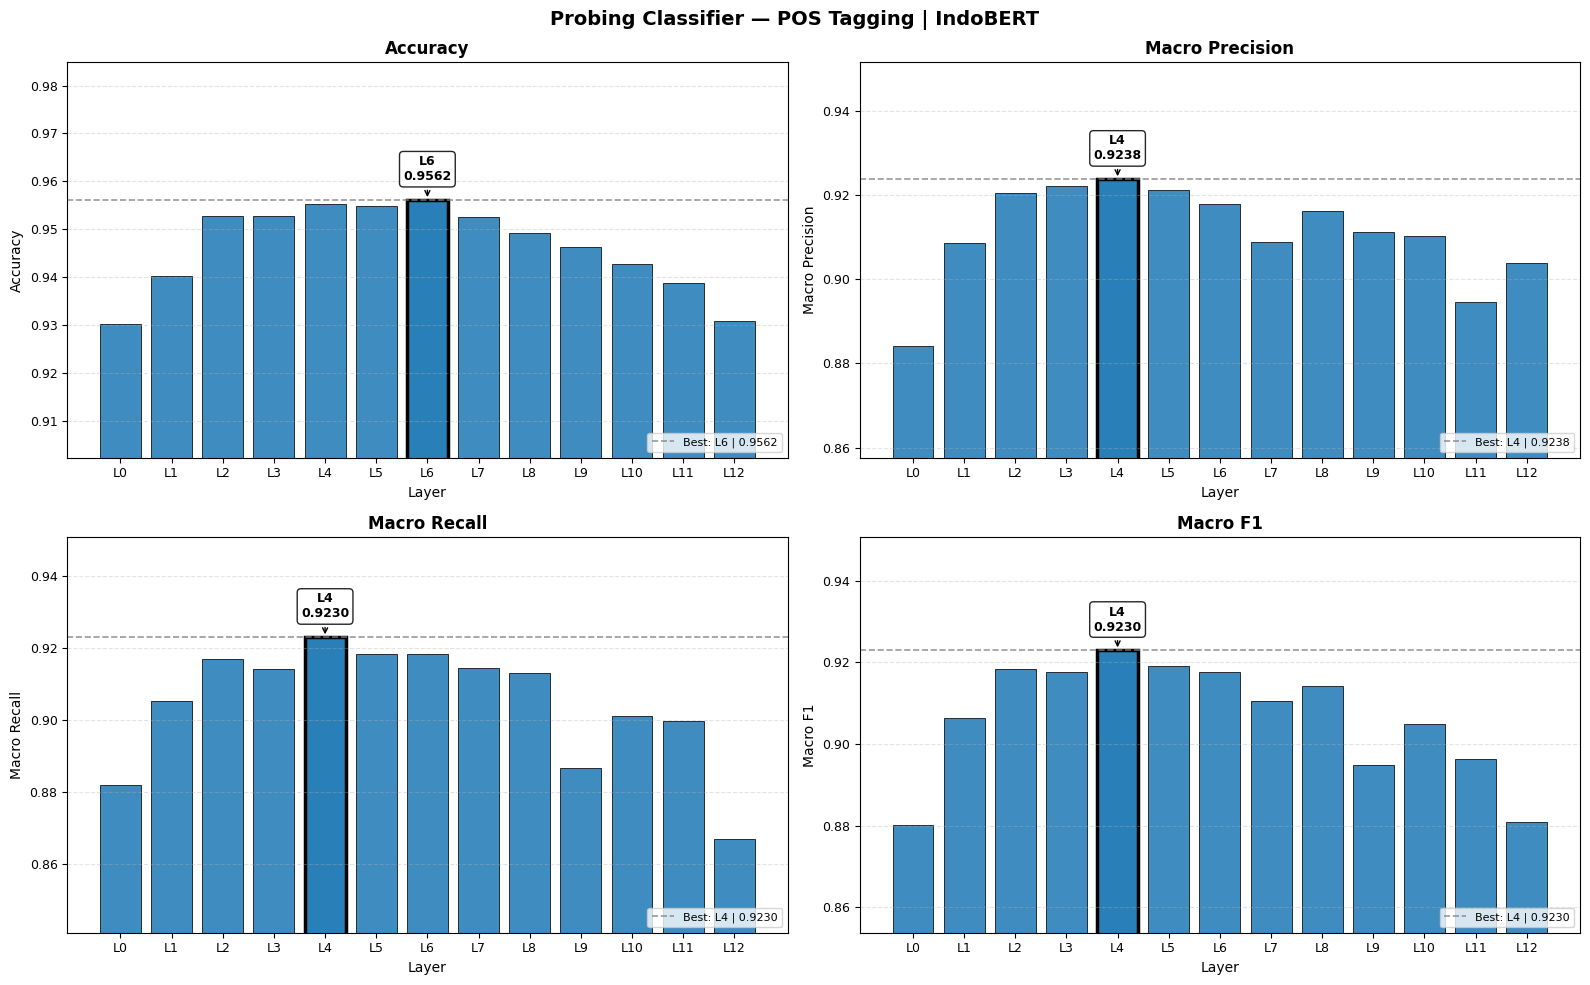

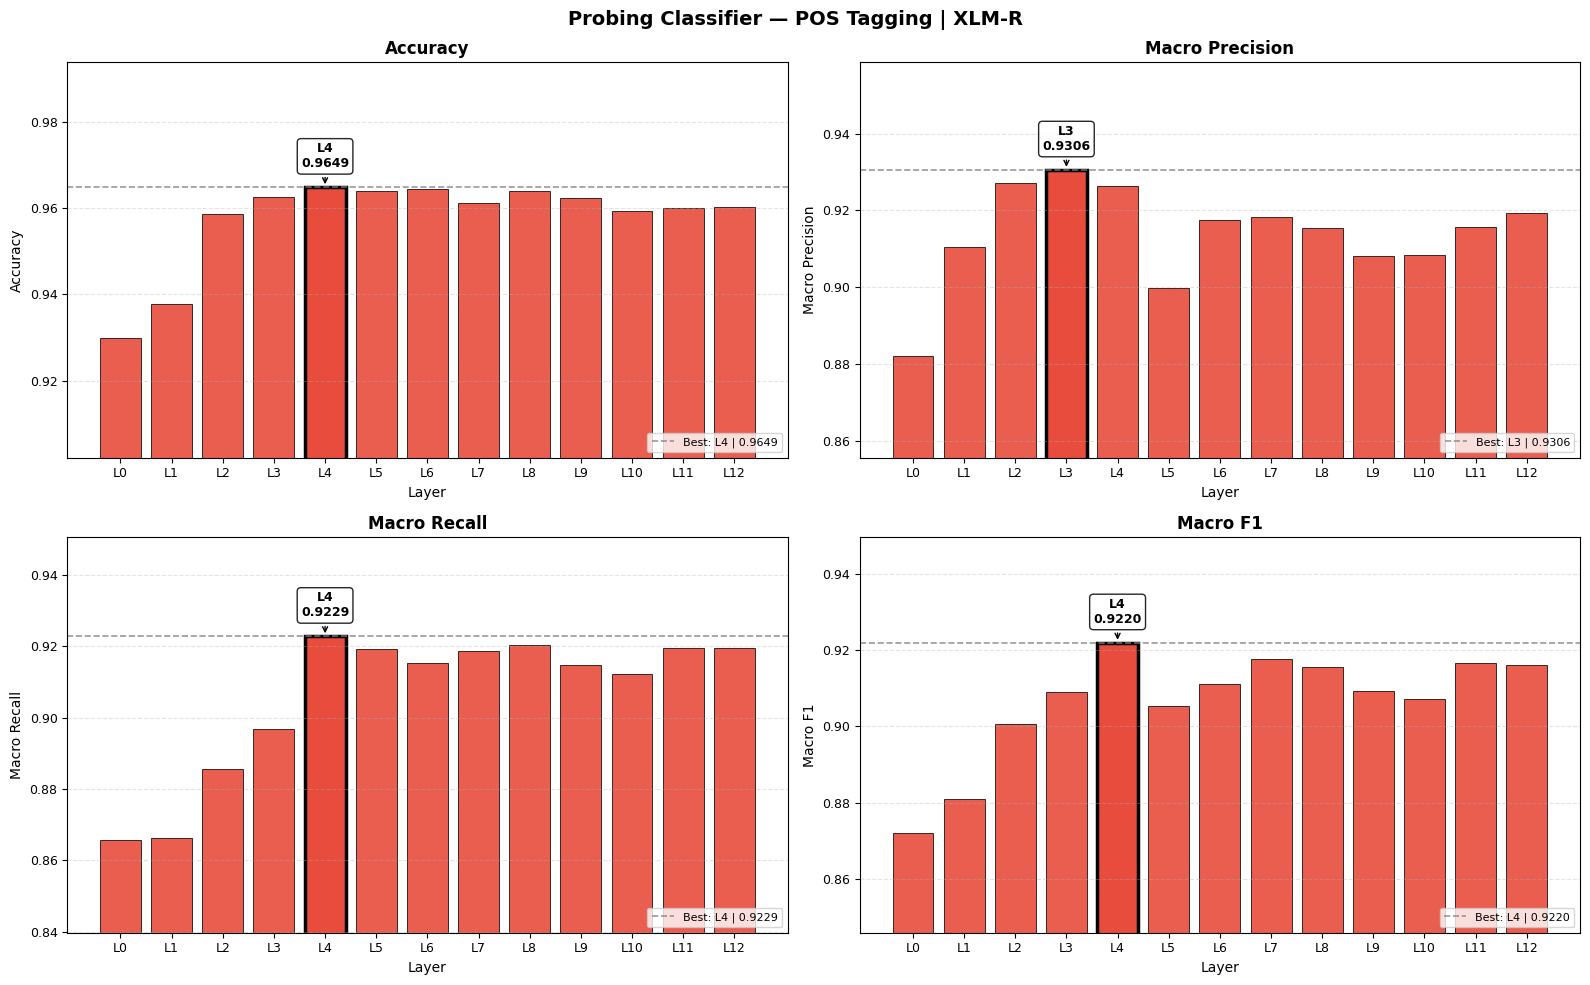

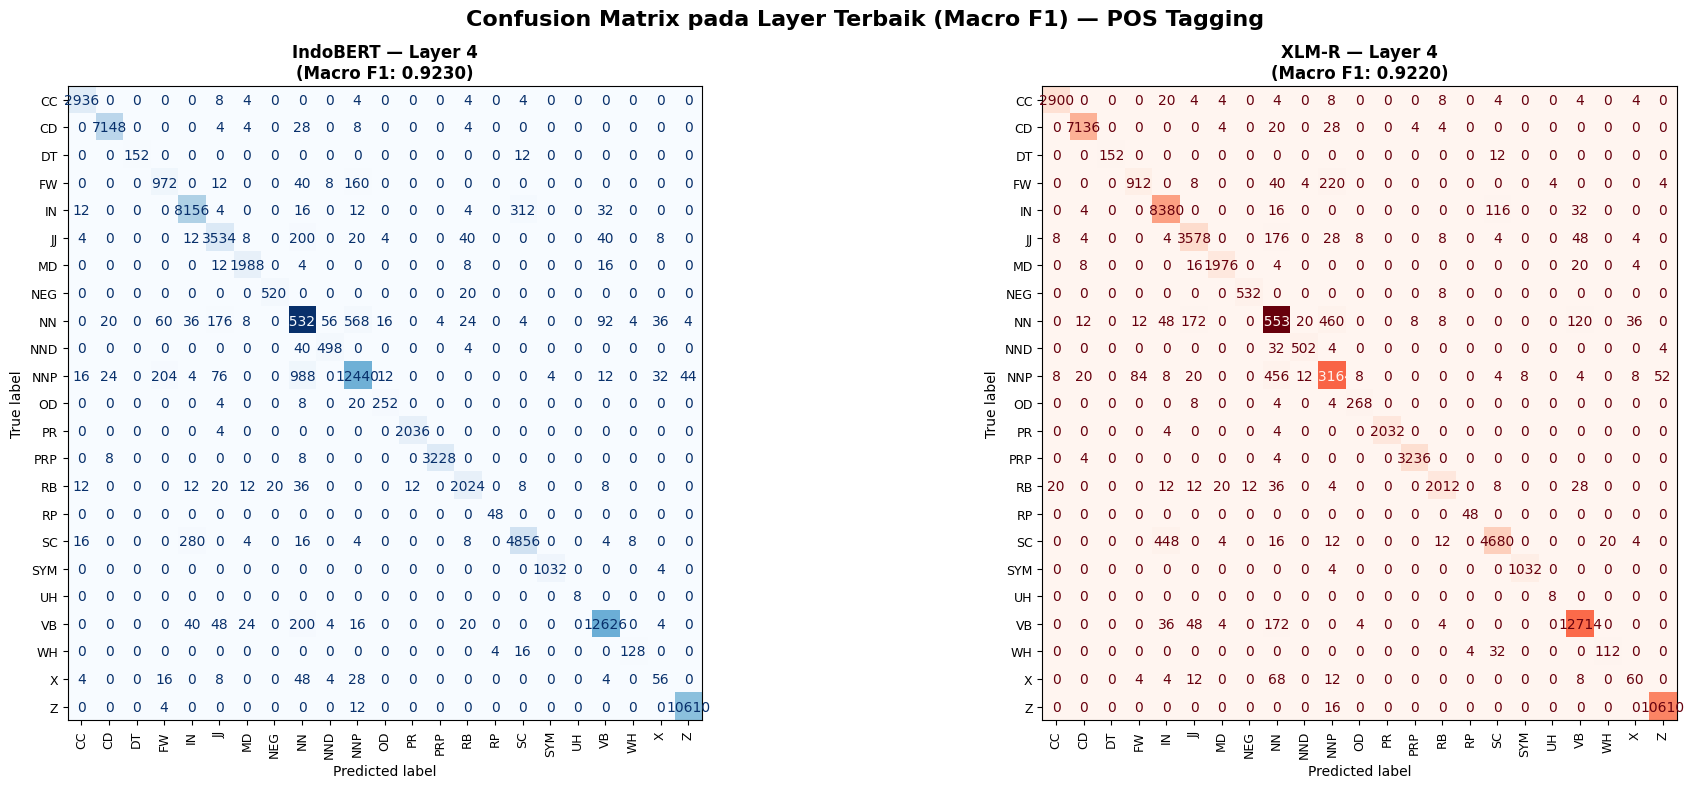

In [ ]:
# ── Fungsi Evaluasi ────────────────────────────────────────
def evaluate_probe(model_path, X_eval, y_eval,
                   hidden_size=768, num_classes=23,
                   return_preds=False):
    probe = LinearProbe(hidden_size, num_classes).to(device)
    probe.load_state_dict(
        torch.load(model_path, map_location=device, weights_only=True)
    )
    probe.eval()

    X_ev = torch.tensor(X_eval, dtype=torch.float32).to(device)
    y_ev = torch.tensor(y_eval, dtype=torch.long)

    with torch.no_grad():
        y_pred = probe(X_ev).argmax(dim=1).cpu().numpy()

    y_np = y_ev.numpy()

    acc  = accuracy_score(y_np, y_pred)
    f1   = f1_score(y_np, y_pred, average='macro', zero_division=0)
    prec = precision_score(y_np, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_np, y_pred, average='macro', zero_division=0)

    if return_preds:
        return acc, f1, prec, rec, y_pred

    return acc, f1, prec, rec


# ── Evaluasi per Layer ─────────────────────────────────────
results_pos = {
    'indobert': {'acc': [], 'f1': [], 'precision': [], 'recall': [], 'y_pred': []},
    'xlmr'    : {'acc': [], 'f1': [], 'precision': [], 'recall': [], 'y_pred': []}
}

TERM_W = 85

print("\n" + "=" * TERM_W)
print("EVALUASI PROBING CLASSIFIER PER LAYER — POS TAGGING".center(TERM_W))
print("=" * TERM_W)
print(
    f"{'Layer':<7}"
    f"{'IB Acc':>8}{'IB P':>8}{'IB R':>8}{'IB mF1':>8} │ "
    f"{'XLM Acc':>8}{'XLM P':>8}{'XLM R':>8}{'XLM mF1':>8}"
)
print("-" * TERM_W)

for layer_idx in range(NUM_LAYERS):
    row = {}

    for model_key, dir_probe in [
        ("indobert", DIR_PROBE_IB),
        ("xlmr",     DIR_PROBE_XLM)
    ]:
        _, X_dev_layer = load_layer_X(model_key, layer_idx)
        model_path = os.path.join(dir_probe, f"probe_L{layer_idx}.pt")

        acc, f1, prec, rec, y_pred = evaluate_probe(
            model_path,
            X_dev_layer,
            y_dev,
            hidden_size=HIDDEN_SIZE,
            num_classes=NUM_CLASSES,
            return_preds=True
        )

        del X_dev_layer
        gc.collect()

        results_pos[model_key]['acc'].append(acc)
        results_pos[model_key]['f1'].append(f1)
        results_pos[model_key]['precision'].append(prec)
        results_pos[model_key]['recall'].append(rec)
        results_pos[model_key]['y_pred'].append(y_pred)

        row[model_key] = (acc, prec, rec, f1)

    acc_i, prec_i, rec_i, f1_i = row['indobert']
    acc_x, prec_x, rec_x, f1_x = row['xlmr']

    print(
        f"L{layer_idx:<6}"
        f"{acc_i:>8.4f}{prec_i:>8.4f}{rec_i:>8.4f}{f1_i:>8.4f} │ "
        f"{acc_x:>8.4f}{prec_x:>8.4f}{rec_x:>8.4f}{f1_x:>8.4f}"
    )

print("=" * TERM_W)


# ── Indeks Layer Terbaik untuk Setiap Metrik ───────────────
best_pos = {
    model: {
        metric: int(np.argmax(results_pos[model][metric]))
        for metric in ['acc', 'f1', 'precision', 'recall']
    }
    for model in ['indobert', 'xlmr']
}


# ── Ringkasan Best Layer — Terminal Style Seragam ──────────
METRICS = [
    ('acc',       'Acc'),
    ('precision', 'Prec'),
    ('recall',    'Rec'),
    ('f1',        'mF1')
]

best_ib_row  = best_pos['indobert']['f1']
best_xlm_row = best_pos['xlmr']['f1']
best_layers_to_show = sorted(set([best_ib_row, best_xlm_row]))

print("\n" + "=" * TERM_W)
print("RINGKASAN BEST LAYER PROBING CLASSIFIER — POS TAGGING".center(TERM_W))
print("=" * TERM_W)
print("Best layer ditentukan berdasarkan Macro F1".center(TERM_W))
print("-" * TERM_W)

print(
    f"{'':7}"
    f"{'── IndoBERT ──':^32} │ "
    f"{'── XLM-R ──':^32} {'Best':>8}"
)

print(
    f"{'Layer':<7}"
    f"{'Acc':>8}{'Prec':>8}{'Rec':>8}{'mF1':>8} │ "
    f"{'Acc':>8}{'Prec':>8}{'Rec':>8}{'mF1':>8} {'':>8}"
)

print("-" * TERM_W)

for i in best_layers_to_show:
    ib_vals = "".join(
        f"{results_pos['indobert'][metric][i]:>8.4f}"
        for metric, _ in METRICS
    )

    xlm_vals = "".join(
        f"{results_pos['xlmr'][metric][i]:>8.4f}"
        for metric, _ in METRICS
    )

    best_tag = []
    if i == best_ib_row:
        best_tag.append("IB")
    if i == best_xlm_row:
        best_tag.append("XLM")

    best_tag = " + ".join(best_tag)

    print(
        f"L{i:<6}"
        f"{ib_vals} │ "
        f"{xlm_vals} {best_tag:>8}"
    )

print("=" * TERM_W)


# ── Visualisasi Bar Chart — Clean dan Informatif ───────────
layer_ticks = [f"L{i}" for i in range(NUM_LAYERS)]

metrics_plot = [
    ('acc',       'Accuracy'),
    ('precision', 'Macro Precision'),
    ('recall',    'Macro Recall'),
    ('f1',        'Macro F1'),
]


# ── Bar Chart IndoBERT ─────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(
    'Probing Classifier — POS Tagging | IndoBERT',
    fontsize=14,
    fontweight='bold'
)

axes = axes.flatten()

for ax, (metric, title) in zip(axes, metrics_plot):
    values = results_pos['indobert'][metric]
    best_layer = best_pos['indobert'][metric]
    best_val = values[best_layer]

    min_val = min(values)
    max_val = max(values)

    y_min = min_val * 0.97
    y_max = max_val * 1.03

    bars = ax.bar(
        layer_ticks,
        values,
        color='#2980b9',
        edgecolor='black',
        linewidth=0.6,
        alpha=0.9
    )

    bars[best_layer].set_edgecolor('black')
    bars[best_layer].set_linewidth(2.5)
    bars[best_layer].set_alpha(1.0)

    ax.axhline(
        best_val,
        linestyle='--',
        linewidth=1.2,
        color='gray',
        alpha=0.8,
        label=f'Best: L{best_layer} | {best_val:.4f}'
    )

    ax.annotate(
        f"L{best_layer}\n{best_val:.4f}",
        xy=(best_layer, best_val),
        xytext=(0, 12),
        textcoords='offset points',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold',
        bbox=dict(
            boxstyle='round,pad=0.3',
            fc='white',
            ec='black',
            alpha=0.85
        ),
        arrowprops=dict(
            arrowstyle='->',
            color='black',
            linewidth=1
        )
    )

    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Layer')
    ax.set_ylabel(title)
    ax.set_ylim(y_min, y_max)
    ax.grid(True, axis='y', linestyle='--', alpha=0.35)
    ax.legend(fontsize=8, loc='lower right')
    ax.tick_params(axis='x', rotation=0)
    ax.tick_params(axis='both', labelsize=9)

plt.tight_layout()
plt.show()


# ── Bar Chart XLM-R ────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(
    'Probing Classifier — POS Tagging | XLM-R',
    fontsize=14,
    fontweight='bold'
)

axes = axes.flatten()

for ax, (metric, title) in zip(axes, metrics_plot):
    values = results_pos['xlmr'][metric]
    best_layer = best_pos['xlmr'][metric]
    best_val = values[best_layer]

    min_val = min(values)
    max_val = max(values)

    y_min = min_val * 0.97
    y_max = max_val * 1.03

    bars = ax.bar(
        layer_ticks,
        values,
        color='#e74c3c',
        edgecolor='black',
        linewidth=0.6,
        alpha=0.9
    )

    bars[best_layer].set_edgecolor('black')
    bars[best_layer].set_linewidth(2.5)
    bars[best_layer].set_alpha(1.0)

    ax.axhline(
        best_val,
        linestyle='--',
        linewidth=1.2,
        color='gray',
        alpha=0.8,
        label=f'Best: L{best_layer} | {best_val:.4f}'
    )

    ax.annotate(
        f"L{best_layer}\n{best_val:.4f}",
        xy=(best_layer, best_val),
        xytext=(0, 12),
        textcoords='offset points',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold',
        bbox=dict(
            boxstyle='round,pad=0.3',
            fc='white',
            ec='black',
            alpha=0.85
        ),
        arrowprops=dict(
            arrowstyle='->',
            color='black',
            linewidth=1
        )
    )

    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Layer')
    ax.set_ylabel(title)
    ax.set_ylim(y_min, y_max)
    ax.grid(True, axis='y', linestyle='--', alpha=0.35)
    ax.legend(fontsize=8, loc='lower right')
    ax.tick_params(axis='x', rotation=0)
    ax.tick_params(axis='both', labelsize=9)

plt.tight_layout()
plt.show()


# ── Confusion Matrix pada Layer Terbaik Macro F1 ───────────
CLASS_NAMES = list(label_encoder.classes_)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle(
    'Confusion Matrix pada Layer Terbaik (Macro F1) — POS Tagging',
    fontsize=16,
    fontweight='bold'
)

for ax, model_key, model_name, color in zip(
    axes,
    ['indobert', 'xlmr'],
    ['IndoBERT', 'XLM-R'],
    ['Blues', 'Reds']
):
    best_layer = best_pos[model_key]['f1']
    best_f1 = results_pos[model_key]['f1'][best_layer]

    cm = confusion_matrix(
        y_dev,
        results_pos[model_key]['y_pred'][best_layer]
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=CLASS_NAMES
    )

    disp.plot(
        ax=ax,
        colorbar=False,
        cmap=color,
        xticks_rotation=90
    )

    ax.set_title(
        f'{model_name} — Layer {best_layer}\n'
        f'(Macro F1: {best_f1:.4f})',
        fontweight='bold'
    )

    ax.tick_params(axis='both', which='major', labelsize=9)

plt.tight_layout()
plt.show()

### 7. Analisis Geometris: Center Kernel Alignment (CKA) - Similarity (POS Tagging)

Memuat sebagian data Test (Sampling) dari disk untuk CKA...
✅ Data CKA siap dengan shape: (1000, 13, 768)
Menghitung CKA internal IndoBERT (POS Tagging)...
Menghitung CKA internal XLM-R (POS Tagging)...
Menghitung CKA cross-model per layer...


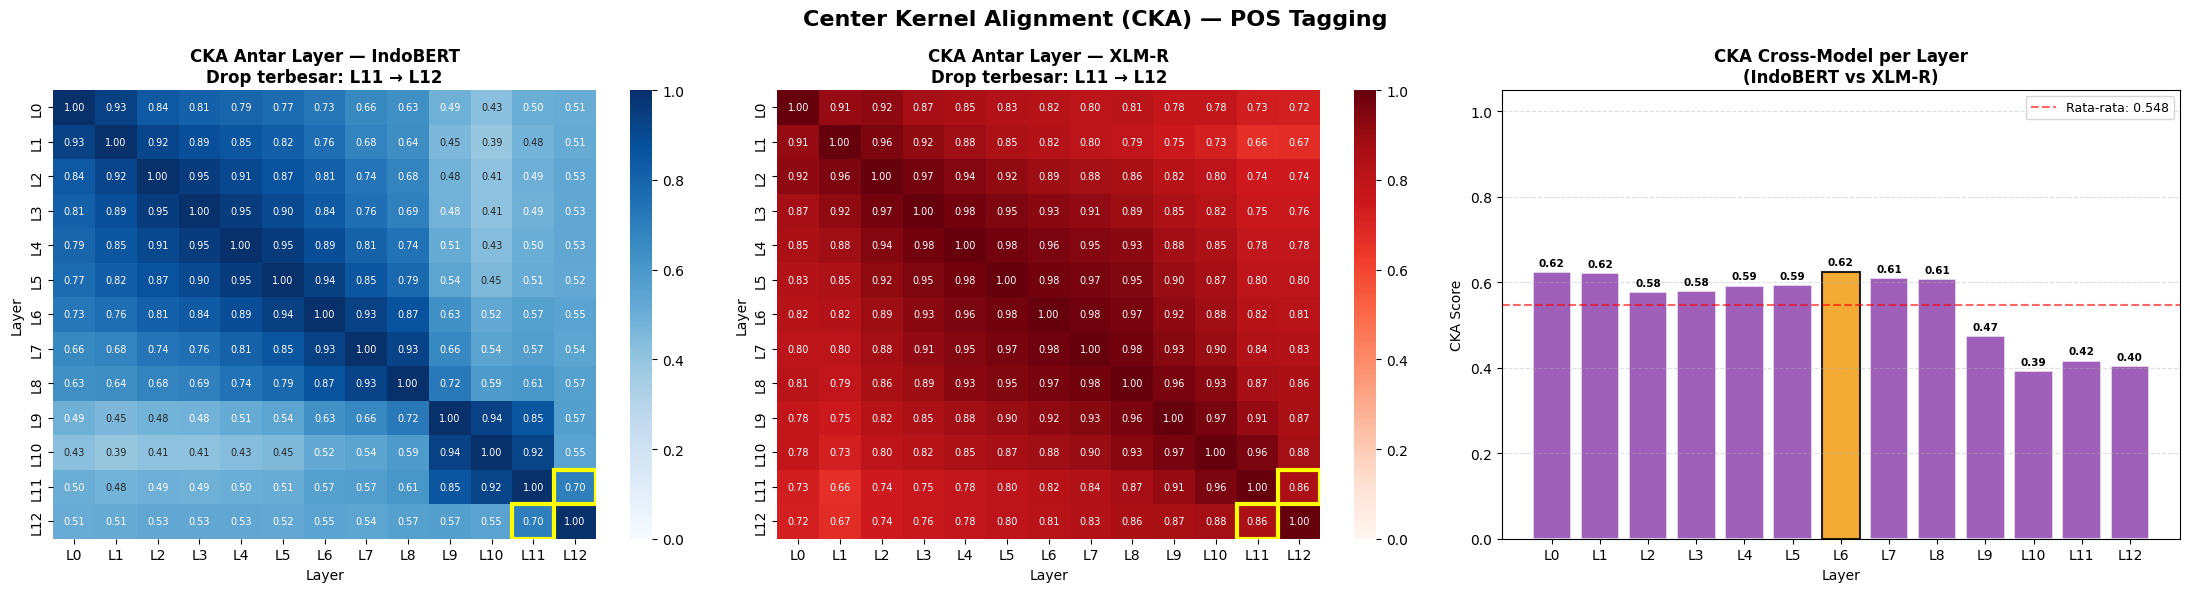

In [ ]:
# ============================================================
# TAHAP 7: CENTER KERNEL ALIGNMENT (CKA) - POS TAGGING
# ============================================================

# ------------------------------------------------------------
# 1) FUNGSI CKA
# ------------------------------------------------------------

def centering(K):
    n = K.shape[0]
    H = np.eye(n) - np.ones((n, n)) / n
    return H @ K @ H

def linear_cka(X, Y):
    K = centering(X @ X.T)
    L = centering(Y @ Y.T)
    num = np.sum(K * L)
    den = np.sqrt(np.sum(K * K)) * np.sqrt(np.sum(L * L))
    return float(num / den) if den > 0 else 0.0

def compute_cka_matrix(X_layers):
    n = X_layers.shape[1]
    M = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            M[i, j] = linear_cka(X_layers[:, i, :], X_layers[:, j, :])
    return M

# ------------------------------------------------------------
# 2) HIGHLIGHT SEQUENTIAL DROP TERBESAR
# ------------------------------------------------------------

def highlight_sequential_max(ax, cka_matrix):
    """
    Highlight pasangan layer berurutan dengan drop terbesar.
    """
    n = cka_matrix.shape[0]
    seq_cka = np.array([cka_matrix[i, i+1] for i in range(n-1)])
    seq_drop = 1 - seq_cka
    best_idx = int(np.argmax(seq_drop))

    # kotak highlight (dua arah karena matriks simetris)
    rect1 = plt.Rectangle((best_idx+1, best_idx), 1, 1,
                          fill=False, edgecolor='yellow', linewidth=3)
    rect2 = plt.Rectangle((best_idx, best_idx+1), 1, 1,
                          fill=False, edgecolor='yellow', linewidth=3)

    ax.add_patch(rect1)
    ax.add_patch(rect2)
    return best_idx, seq_cka, seq_drop

# ------------------------------------------------------------
# 3) SAMPLING DATA (Load-on-the-fly untuk Hemat RAM)
# ------------------------------------------------------------
layer_ticks = [f"L{i}" for i in range(NUM_LAYERS)]

MAX_CKA = 1000
total_test_samples = len(y_test) # Memanfaatkan y_test dari Tahap 5 yang masih di RAM

np.random.seed(42) # Agar index random yang dipilih selalu konsisten
idx_cka = np.random.choice(
    total_test_samples,
    size=min(MAX_CKA, total_test_samples),
    replace=False
)

# Siapkan matriks kosong dengan presisi float16 agar sangat ringan
X_cka_ib  = np.zeros((len(idx_cka), NUM_LAYERS, HIDDEN_SIZE), dtype=np.float16)
X_cka_xlm = np.zeros((len(idx_cka), NUM_LAYERS, HIDDEN_SIZE), dtype=np.float16)

print("Memuat sebagian data Test (Sampling) dari disk untuk CKA...")

for i in range(NUM_LAYERS):
    # Load spesifik layer i untuk IndoBERT
    tmp_ib = np.load(os.path.join(SAVE_DIR, f"indobert_pos_test_L{i}.npz"))
    X_cka_ib[:, i, :] = tmp_ib['X'][idx_cka]  # Hanya ambil baris sesuai idx_cka
    
    # Load spesifik layer i untuk XLM-R
    tmp_xlm = np.load(os.path.join(SAVE_DIR, f"xlmr_pos_test_L{i}.npz"))
    X_cka_xlm[:, i, :] = tmp_xlm['X'][idx_cka]
    
    del tmp_ib, tmp_xlm # Hapus dari RAM
    gc.collect()

print(f"✅ Data CKA siap dengan shape: {X_cka_ib.shape}")

# ------------------------------------------------------------
# 4) HITUNG CKA
# ------------------------------------------------------------

print("Menghitung CKA internal IndoBERT (POS Tagging)...")
cka_ib = compute_cka_matrix(X_cka_ib)

print("Menghitung CKA internal XLM-R (POS Tagging)...")
cka_xlm = compute_cka_matrix(X_cka_xlm)

print("Menghitung CKA cross-model per layer...")
cka_cross = np.array([
    linear_cka(X_cka_ib[:, i, :], X_cka_xlm[:, i, :])
    for i in range(NUM_LAYERS)
])

# ------------------------------------------------------------
# 5) VISUALISASI
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle('Center Kernel Alignment (CKA) — POS Tagging',
             fontsize=16, fontweight='bold')

# ── Heatmap IndoBERT ────────────────────────────────────────
sns.heatmap(
    cka_ib,
    ax=axes[0],
    xticklabels=layer_ticks,
    yticklabels=layer_ticks,
    vmin=0, vmax=1,
    cmap='Blues',
    annot=True,
    fmt='.2f',
    annot_kws={'size': 7}
)

best_ib_idx, seq_cka_ib, seq_drop_ib = highlight_sequential_max(axes[0], cka_ib)

axes[0].set_title(
    f'CKA Antar Layer — IndoBERT\nDrop terbesar: L{best_ib_idx} → L{best_ib_idx+1}',
    fontweight='bold'
)
axes[0].set_xlabel('Layer')
axes[0].set_ylabel('Layer')

# ── Heatmap XLM-R ───────────────────────────────────────────
sns.heatmap(
    cka_xlm,
    ax=axes[1],
    xticklabels=layer_ticks,
    yticklabels=layer_ticks,
    vmin=0, vmax=1,
    cmap='Reds',
    annot=True,
    fmt='.2f',
    annot_kws={'size': 7}
)

best_xlm_idx, seq_cka_xlm, seq_drop_xlm = highlight_sequential_max(axes[1], cka_xlm)

axes[1].set_title(
    f'CKA Antar Layer — XLM-R\nDrop terbesar: L{best_xlm_idx} → L{best_xlm_idx+1}',
    fontweight='bold'
)
axes[1].set_xlabel('Layer')
axes[1].set_ylabel('Layer')

# ── Cross-model Bar Chart ───────────────────────────────────
bars = axes[2].bar(
    layer_ticks,
    cka_cross,
    color='#8e44ad',
    alpha=0.85,
    edgecolor='white',
    linewidth=1.2
)

best_cross = int(np.argmax(cka_cross))

bars[best_cross].set_color('#f39c12')
bars[best_cross].set_edgecolor('black')
bars[best_cross].set_linewidth(1.5)

axes[2].set_title('CKA Cross-Model per Layer\n(IndoBERT vs XLM-R)',
                  fontweight='bold')
axes[2].set_xlabel('Layer')
axes[2].set_ylabel('CKA Score')
axes[2].set_ylim(0, 1.05)

axes[2].axhline(
    y=np.mean(cka_cross),
    color='red',
    linestyle='--',
    alpha=0.6,
    label=f'Rata-rata: {np.mean(cka_cross):.3f}'
)

axes[2].legend(fontsize=9)
axes[2].grid(True, linestyle='--', alpha=0.4, axis='y')

for i, val in enumerate(cka_cross):
    axes[2].text(i, val + 0.01, f'{val:.2f}',
                 ha='center', va='bottom',
                 fontsize=7.5, fontweight='bold')

plt.tight_layout()
plt.show()